# LSTM Experiments — Portfolio, Static Descriptors, and Inertia

This notebook trains and evaluates LSTM models for **1-hour ahead heat demand forecasting** on the TalTech campus.

It reuses the exported feature datasets from `03_feature_engineering_10032026.ipynb` and the baselines from `02_establishing_baselines_10032026.ipynb`, but the active experiment design is defined **explicitly inside this notebook**.

The key modeling choices are now intentionally lean:

- a compact **base temporal core** with raw heat history, weather-now, and calendar signals,
- a compact **inertia-aware temporal extension** with one weather-memory channel plus system `deltaT` / low-`deltaT` signals,
- and a lean **static descriptor block** used only in the temporal-plus-static experiments.

This keeps the LSTM setup readable without digging through upstream notebooks, while still relying on `03` for the cleaned feature files.

---

## Section 0 — Imports, configuration, and paths

In this section we:

- Import core libraries (NumPy, pandas, Matplotlib, TensorFlow/Keras, scikit-learn).
- Set global seeds for reproducibility.
- Define all configuration in one place (paths, date splits, LSTM hyperparameters).
- Print a short summary of the project paths and cohorts.


In [1]:
# Section 0 — Imports, configuration, and paths

from __future__ import annotations

from pathlib import Path
import os
import json
import logging
import warnings

# Silence TensorFlow C++ runtime noise before importing tensorflow.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["AUTOGRAPH_VERBOSITY"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    tf.get_logger().setLevel("ERROR")
except Exception:
    pass

try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
    absl.logging.set_stderrthreshold("error")
except Exception:
    pass

warnings.filterwarnings("ignore", message=".*use_unbounded_threadpool.*")
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    # Available in TF 2.20+, may be a no-op otherwise
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# ---------------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------------

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
FEATURE_DIR = DATA_DIR / "features"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_METADATA_FILE = FEATURE_DIR / "feature_metadata.csv"
PORTFOLIO_COVERAGE_FILE = FEATURE_DIR / "portfolio_coverage.csv"
FEATURE_CATALOG_FILE = FEATURE_DIR / "feature_catalog.csv"
BASELINE_SUMMARY_FILE = RESULTS_DIR / "baseline_summary.json"

# ---------------------------------------------------------------------------
# Global experiment configuration
# ---------------------------------------------------------------------------

CONFIG = {
    # Time windows
    "TRAIN_END": "2023-09-30",
    "VAL_START": "2023-10-01",
    "TEST_START": "2024-01-01",
    # Sequence and model hyperparameters
    "LOOKBACK_HOURS": 24,
    "BATCH_SIZE": 64,
    "EPOCHS": 50,
    "LEARNING_RATE": 1e-3,
    "EARLY_STOPPING_PATIENCE": 7,
    # Data quality / filtering
    "MAX_GAP_HOURS": 3,
    "MIN_EVAL_ROWS": 1000,
}

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

print(f"Project root    : {PROJECT_ROOT}")
print(f"Feature dir     : {FEATURE_DIR}")
print(f"Feature catalog : {FEATURE_CATALOG_FILE.name} (validation only)")
print(f"Results dir     : {RESULTS_DIR}")
print(f"Config          : {CONFIG}")



Project root    : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project
Feature dir     : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/features
Feature catalog : feature_catalog.csv (validation only)
Results dir     : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results
Config          : {'TRAIN_END': '2023-09-30', 'VAL_START': '2023-10-01', 'TEST_START': '2024-01-01', 'LOOKBACK_HOURS': 24, 'BATCH_SIZE': 64, 'EPOCHS': 50, 'LEARNING_RATE': 0.001, 'EARLY_STOPPING_PATIENCE': 7, 'MAX_GAP_HOURS': 3, 'MIN_EVAL_ROWS': 1000}


## Section 1 — Load feature metadata and define explicit experiment feature lists

In this section we:

- Load the per-building feature metadata from `feature_metadata.csv`.
- Load the portfolio coverage table from `portfolio_coverage.csv`.
- Optionally load `feature_catalog.csv` only as a validation backstop.
- Define the active LSTM feature lists **directly in this notebook**:
  - `setA` temporal-only lean sequence features,
  - `setB` temporal lean sequence features plus a lean static descriptor block.
- Print the exact feature lists so the experiment definition is visible before any training starts.
- Define the two main experiment cohorts:
  - **COHORT_A** — all 17 buildings for temporal-only runs.
  - **COHORT_B** — buildings with complete lean static vectors for temporal-plus-static runs.


In [2]:
# Section 1 — Load feature metadata, optional feature catalog, and define explicit experiment feature lists

# 1a. Load feature metadata (paths to setA / setB per building)
feature_meta = pd.read_csv(FEATURE_METADATA_FILE)

# 1b. Load portfolio coverage (train/test completeness and static availability)
portfolio_cov = pd.read_csv(PORTFOLIO_COVERAGE_FILE, parse_dates=["first_obs", "last_obs"])

# 1c. Load feature catalog only as a validation backstop.
feature_catalog = None
if FEATURE_CATALOG_FILE.exists():
    feature_catalog = pd.read_csv(FEATURE_CATALOG_FILE)
    print("Loaded feature_catalog.csv for validation checks.")
else:
    print("[WARN] feature_catalog.csv not found; proceeding with explicit notebook-local feature lists only.")


def _coerce_bool_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    mapped = series.astype(str).str.strip().str.lower().map({
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    })
    return mapped.fillna(False)


def _unique_keep_order(items):
    seen = set()
    out = []
    for item in items:
        if item not in seen:
            seen.add(item)
            out.append(item)
    return out


# Explicit lean temporal feature design used by this notebook.
LSTM_BASE_TEMPORAL_FEATURES = [
    "feat_heat_obs",
    "feat_outdoor_temp_c",
    "feat_wind_ms",
    "feat_solar_irradiance_wm2",
    "feat_hour_sin",
    "feat_hour_cos",
    "feat_dow_sin",
    "feat_dow_cos",
]

LSTM_WEATHER_MEMORY_FEATURES = [
    "feat_temp_roll24h",
]

LSTM_SYSTEM_DYNAMIC_FEATURES = [
    "feat_space_heat_active",
    "feat_space_deltaT_c",
    "feat_space_low_deltaT_flag",
    "feat_vent_heat_active",
    "feat_vent_deltaT_c",
    "feat_vent_low_deltaT_flag",
]

LSTM_INERTIA_TEMPORAL_FEATURES = _unique_keep_order(
    LSTM_BASE_TEMPORAL_FEATURES
    + LSTM_WEATHER_MEMORY_FEATURES
    + LSTM_SYSTEM_DYNAMIC_FEATURES
)

LSTM_STATIC_FEATURES_SETB = [
    "stat_heated_area_m2",
    "stat_usage_non_res_share_of_heated",
    "stat_building_age_years",
    "stat_n_points",
    "stat_n_heat_points",
    "stat_n_vent_points",
    "stat_n_dhw_points",
    "stat_vent_class_basic",
    "stat_vent_class_none",
    "stat_vent_class_rich",
    "stat_ventilation_has_heat_recovery",
    "ehr_compactness_ratio",
    "ehr_max_floors",
    "ehr_volume_per_heated_area",
    "stat_missing_heated_area_m2",
    "stat_missing_usage_non_res_share_of_heated",
    "stat_missing_building_age_years",
    "ehr_missing_compactness_ratio",
    "ehr_missing_max_floors",
    "ehr_missing_volume_per_heated_area",
]

EXPERIMENT_FEATURE_GROUPS = {
    "base_core": LSTM_BASE_TEMPORAL_FEATURES,
    "weather_memory": LSTM_WEATHER_MEMORY_FEATURES,
    "system_dynamic": LSTM_SYSTEM_DYNAMIC_FEATURES,
    "calendar": [c for c in LSTM_BASE_TEMPORAL_FEATURES if c.startswith("feat_hour_") or c.startswith("feat_dow_")],
    "static_building": LSTM_STATIC_FEATURES_SETB,
}

TEMPORAL_FEATURES_BY_SET = {
    "setA": LSTM_INERTIA_TEMPORAL_FEATURES.copy(),
    "setB": LSTM_INERTIA_TEMPORAL_FEATURES.copy(),
}
STATIC_FEATURES_SETB = LSTM_STATIC_FEATURES_SETB.copy()

# 1d. Load baseline summary JSON (for later comparison)
baseline_summary = None
if BASELINE_SUMMARY_FILE.exists():
    with open(BASELINE_SUMMARY_FILE, "r", encoding="utf-8") as f:
        baseline_summary = json.load(f)
    print("Loaded baseline_summary.json (as dict)")
else:
    print("[WARN] baseline_summary.json not found; baseline comparisons will be limited.")

# 1e. Define cohorts
ALL_BUILDINGS = feature_meta["building"].tolist()
STATIC_COMPLETE_BUILDINGS = portfolio_cov.loc[
    _coerce_bool_series(portfolio_cov["static_complete_any"]), "building"
].tolist()

COHORT_A = ALL_BUILDINGS
COHORT_B = [b for b in ALL_BUILDINGS if b in STATIC_COMPLETE_BUILDINGS]

print()
print("Feature metadata (head):")
print(feature_meta.head().to_string(index=False))

print()
print("Portfolio coverage (head):")
print(portfolio_cov.head().to_string(index=False))

if feature_catalog is not None:
    required_catalog_cols = {"feature_name", "feature_group", "in_setA", "in_setB", "is_static", "source"}
    missing_catalog_cols = required_catalog_cols - set(feature_catalog.columns)
    if missing_catalog_cols:
        raise ValueError(f"feature_catalog.csv is missing columns: {sorted(missing_catalog_cols)}")
    print()
    print("Feature catalog summary (validation only):")
    print(feature_catalog.groupby(["feature_group", "is_static"])["feature_name"].count().rename("n_features").reset_index().to_string(index=False))

print()
print("Explicit lean feature lists used in this notebook:")
print("Base temporal core:", LSTM_BASE_TEMPORAL_FEATURES)
print("Weather-memory extension:", LSTM_WEATHER_MEMORY_FEATURES)
print("System/inertia extension:", LSTM_SYSTEM_DYNAMIC_FEATURES)
print("Lean temporal set (used for scaling / full M3):", TEMPORAL_FEATURES_BY_SET["setA"])
print("Lean static setB block:", STATIC_FEATURES_SETB)

print()
print("Feature set sizes:")
print({
    "setA_temporal": len(TEMPORAL_FEATURES_BY_SET["setA"]),
    "setB_temporal": len(TEMPORAL_FEATURES_BY_SET["setB"]),
    "setB_static": len(STATIC_FEATURES_SETB),
})

print()
print("Cohorts:")
print(f"COHORT_A (temporal-only): {COHORT_A}")
print(f"COHORT_B (temporal-plus-static): {COHORT_B}")


Loaded feature_catalog.csv for validation checks.
Loaded baseline_summary.json (as dict)

Feature metadata (head):
building                           path_setA                           path_setB  n_rows_setA  n_rows_setB  n_features_setA  n_features_setB       target_columns
     GEO data/features/GEO_features_setA.csv data/features/GEO_features_setB.csv        22884        22884               51              141 heat_kwh,heat_kwh_m2
     ICO data/features/ICO_features_setA.csv data/features/ICO_features_setB.csv        22955        22955               51              141 heat_kwh,heat_kwh_m2
     LIB data/features/LIB_features_setA.csv data/features/LIB_features_setB.csv        22954        22954               51              141 heat_kwh,heat_kwh_m2
     SOC data/features/SOC_features_setA.csv data/features/SOC_features_setB.csv        22954        22954               51              141 heat_kwh,heat_kwh_m2
     STU data/features/STU_features_setA.csv data/features/STU_features_set

## Section 2 — Load feature frames and basic quality checks

In this section we:

- Load the per-building feature frames for setA and setB using the metadata table.
- Ensure the datetime index is clean: timezone-naive, sorted, hourly frequency.
- Run basic target checks for `heat_kwh` (NaNs, negatives, extreme values).
- Summarise coverage per building (rows, first/last timestamp) for a quick sanity check.

These checks should be fast and give us confidence that the feature exports from the previous notebook are usable before we start defining splits and sequences.

Feature frame summary (setA, per building):
building  rows            first_ts             last_ts freq_inferred  heat_na_frac  heat_min   heat_max  heat_has_negative
     GEO 22884 2022-05-23 12:00:00 2024-12-31 23:00:00             h           0.0       0.0 565.172307              False
     ICO 22955 2022-05-20 13:00:00 2024-12-31 23:00:00             h           0.0       0.0 154.000000              False
     LIB 22954 2022-05-20 14:00:00 2024-12-31 23:00:00             h           0.0       0.0 317.000000              False
     SOC 22954 2022-05-20 14:00:00 2024-12-31 23:00:00             h           0.0       0.0 628.000000              False
     STU 17607 2022-01-01 01:00:00 2024-01-04 15:00:00             h           0.0       0.0 188.000000              False
     U01 22954 2022-05-20 14:00:00 2024-12-31 23:00:00             h           0.0       0.0 342.500000              False
  U01U02 17745 2022-01-01 02:00:00 2024-01-10 10:00:00             h           0.0       0.0 61

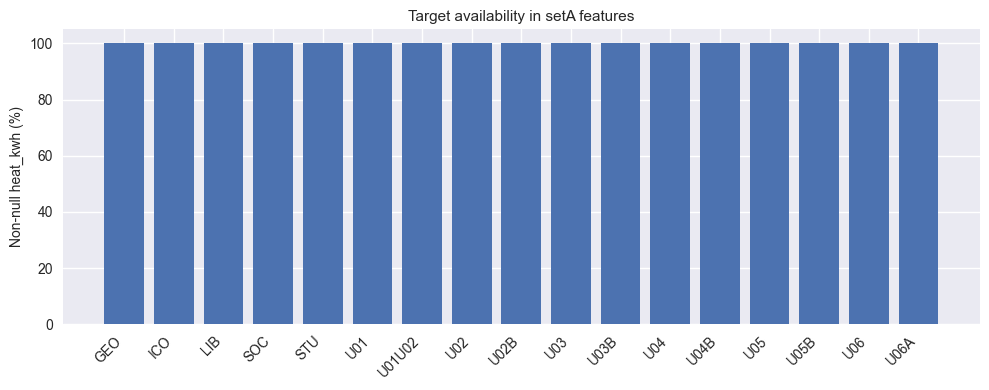

In [3]:
# Section 2 — Load feature frames and basic quality checks

from typing import Dict, Tuple

# 2a. Helpers to load a single feature frame

def _load_feature_frame(path_str: str) -> pd.DataFrame:
    """Load a feature CSV (setA or setB) and return a DataFrame with datetime index.

    The file is expected to have a 'datetime' index column created in the
    feature-engineering notebook.
    """
    csv_path = PROJECT_ROOT / path_str
    if not csv_path.exists():
        raise FileNotFoundError(f"Feature file not found: {csv_path}")

    df = pd.read_csv(csv_path, parse_dates=["datetime"])
    df = df.set_index("datetime").sort_index()

    # Make sure index is tz-naive
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    return df


features_setA: Dict[str, pd.DataFrame] = {}
features_setB: Dict[str, pd.DataFrame] = {}

# 2b. Load all buildings for setA and setB

for _, row in feature_meta.iterrows():
    bldg = row["building"]
    path_A = row["path_setA"]
    path_B = row["path_setB"]

    df_A = _load_feature_frame(path_A)
    features_setA[bldg] = df_A

    df_B = _load_feature_frame(path_B)
    features_setB[bldg] = df_B

# 2c. Validate that the explicit feature lists exist in the loaded frames.
missing_rows = []
for bldg in ALL_BUILDINGS:
    df_A = features_setA[bldg]
    df_B = features_setB[bldg]

    missing_A = sorted(set(TEMPORAL_FEATURES_BY_SET["setA"] + ["heat_kwh"]) - set(df_A.columns))
    missing_B_temporal = sorted(set(TEMPORAL_FEATURES_BY_SET["setB"] + ["heat_kwh"]) - set(df_B.columns))
    missing_B_static = sorted(set(STATIC_FEATURES_SETB) - set(df_B.columns))

    if missing_A or missing_B_temporal or missing_B_static:
        missing_rows.append({
            "building": bldg,
            "missing_setA": missing_A,
            "missing_setB_temporal": missing_B_temporal,
            "missing_setB_static": missing_B_static,
        })

if missing_rows:
    raise ValueError("Explicit LSTM feature lists are missing from the loaded feature frames: " + str(missing_rows[:3]))

# 2d. Basic quality summary
summary_rows = []

for bldg in ALL_BUILDINGS:
    df_A = features_setA[bldg]
    heat = df_A["heat_kwh"]

    idx = df_A.index
    freq = pd.infer_freq(idx)

    summary_rows.append({
        "building": bldg,
        "rows": len(df_A),
        "first_ts": idx.min(),
        "last_ts": idx.max(),
        "freq_inferred": freq,
        "heat_na_frac": float(heat.isna().mean()),
        "heat_min": float(heat.min(skipna=True) if heat.notna().any() else float("nan")),
        "heat_max": float(heat.max(skipna=True) if heat.notna().any() else float("nan")),
        "heat_has_negative": bool((heat < 0).any()),
    })

quality_df = pd.DataFrame(summary_rows).sort_values("building").reset_index(drop=True)

print("Feature frame summary (setA, per building):")
print(quality_df.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(quality_df["building"], (1 - quality_df["heat_na_frac"]) * 100.0)
plt.ylabel("Non-null heat_kwh (%)")
plt.title("Target availability in setA features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Section 3 — Time splits and gap-length checks

Here we:

- Define **train**, **validation**, and **test** masks per building using the global dates in `CONFIG`.
- Verify that the splits are strictly chronological and non-overlapping.
- Compute a simple **gap-length report** based on the datetime index, to flag any jumps larger than 1 hour.
- Summarise per-building row counts per split and mark buildings that fall below the `MIN_EVAL_ROWS` threshold for core reporting.

This section is still purely diagnostic; no scaling or sequence creation yet.

Split summary (rows per building):
building  rows_total  rows_train  rows_val  rows_test  large_gaps_gt_MAX_GAP_HOURS
     GEO       22884       11869      2208       8784                            0
     ICO       22955       11940      2208       8784                            0
     LIB       22954       11939      2208       8784                            0
     SOC       22954       11939      2208       8784                            0
     STU       17607       15288      2208         88                            0
     U01       22954       11939      2208       8784                            0
  U01U02       17745       15287      2208        227                            0
     U02       22925       11939      2208       8755                            0
    U02B       22925       11939      2208       8755                            0
     U03       22925       11939      2208       8755                            0
    U03B       21596       10610      2208       875

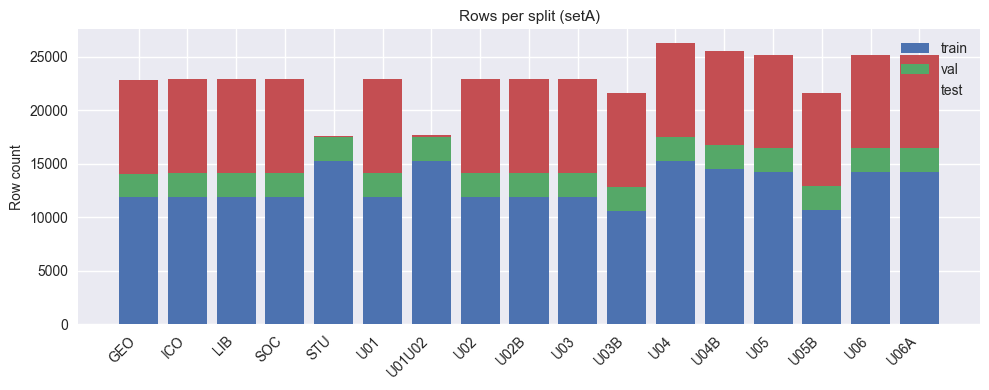


Core buildings for reporting (setA, rows_test >= 1000):
['GEO', 'ICO', 'LIB', 'SOC', 'U01', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']


In [4]:
# Section 3 — Time splits and gap-length checks

TRAIN_END = pd.Timestamp(CONFIG["TRAIN_END"])
VAL_START = pd.Timestamp(CONFIG["VAL_START"])
TEST_START = pd.Timestamp(CONFIG["TEST_START"])

assert TRAIN_END < VAL_START < TEST_START, "CONFIG date order must satisfy TRAIN_END < VAL_START < TEST_START"

split_info_rows = []
SPLITS = {}  # building -> dict of boolean masks

for bldg in ALL_BUILDINGS:
    df = features_setA[bldg]
    idx = df.index

    # Basic monotonicity and frequency check (already inspected in Section 2)
    assert idx.is_monotonic_increasing, f"Index not monotonic for {bldg}"

    train_mask = idx <= TRAIN_END
    val_mask = (idx >= VAL_START) & (idx < TEST_START)
    test_mask = idx >= TEST_START

    # No overlaps
    assert not (train_mask & val_mask).any(), f"Train/val overlap for {bldg}"
    assert not (train_mask & test_mask).any(), f"Train/test overlap for {bldg}"
    assert not (val_mask & test_mask).any(), f"Val/test overlap for {bldg}"

    SPLITS[bldg] = {
        "train": train_mask,
        "val": val_mask,
        "test": test_mask,
    }

    # Gap-length analysis based on datetime index (in hours)
    if len(idx) > 1:
        deltas = idx.to_series().diff().dropna()
        gap_hours = (deltas.dt.total_seconds() / 3600.0).astype(float) - 1.0
        n_large_gaps = int((gap_hours > CONFIG["MAX_GAP_HOURS"]).sum())
    else:
        n_large_gaps = 0

    split_info_rows.append({
        "building": bldg,
        "rows_total": int(len(df)),
        "rows_train": int(train_mask.sum()),
        "rows_val": int(val_mask.sum()),
        "rows_test": int(test_mask.sum()),
        "large_gaps_gt_MAX_GAP_HOURS": n_large_gaps,
    })

split_df = pd.DataFrame(split_info_rows).sort_values("building").reset_index(drop=True)

print("Split summary (rows per building):")
print(split_df.to_string(index=False))

# Quick stacked bar plot of rows per split (setA)
plt.figure(figsize=(10, 4))
bar_x = np.arange(len(split_df))
plt.bar(bar_x, split_df["rows_train"], label="train")
plt.bar(bar_x, split_df["rows_val"], bottom=split_df["rows_train"], label="val")
plt.bar(bar_x, split_df["rows_test"],
        bottom=split_df["rows_train"] + split_df["rows_val"], label="test")
plt.xticks(bar_x, split_df["building"], rotation=45, ha="right")
plt.ylabel("Row count")
plt.title("Rows per split (setA)")
plt.legend()
plt.tight_layout()
plt.show()

# Identify "core" buildings with enough test rows
CORE_BUILDINGS_A = split_df.loc[
    split_df["rows_test"] >= CONFIG["MIN_EVAL_ROWS"], "building"
].tolist()

print(f"\nCore buildings for reporting (setA, rows_test >= {CONFIG['MIN_EVAL_ROWS']}):")
print(CORE_BUILDINGS_A)


## Section 4 — Preprocessors (temporal and static scalers)

Now we prepare the preprocessing building blocks that will be reused by all experiments:

- **Per-building StandardScaler** for the explicit lean temporal feature lists used in `setA` and `setB`.
- **Per-building StandardScaler** for the target `heat_kwh` (fit on train rows only).
- **Global StandardScaler** for the lean static `setB` feature block (fit on one building-level vector per building).

Unlike the previous catalog-driven version, the active columns are the explicit lists printed in Section 1. The catalog is only used as a safety check, not as the experiment definition.

We also run a small check to confirm that inverse-transforming the scaled target recovers the original values within numerical tolerance.


In [5]:
# Section 4 — Preprocessors (temporal and static scalers)

SETA_TEMPORAL_FEATURES = TEMPORAL_FEATURES_BY_SET["setA"].copy()
SETB_TEMPORAL_FEATURES = TEMPORAL_FEATURES_BY_SET["setB"].copy()
STATIC_FEATURES = STATIC_FEATURES_SETB.copy()

# Per-building temporal feature and target scalers
temporal_feature_scalers: Dict[str, Dict[str, StandardScaler]] = {"setA": {}, "setB": {}}
target_scalers: Dict[str, StandardScaler] = {}

# Global static scaler (fit on one building-level vector per building)
static_feature_scaler = StandardScaler()

# 4a. Fit per-building scalers on setA / setB temporal blocks and the target
for bldg in ALL_BUILDINGS:
    train_mask = SPLITS[bldg]["train"]

    for feature_set, df, temporal_cols in [
        ("setA", features_setA[bldg], SETA_TEMPORAL_FEATURES),
        ("setB", features_setB[bldg], SETB_TEMPORAL_FEATURES),
    ]:
        X_train = df.loc[train_mask, temporal_cols].values
        scaler = StandardScaler()
        scaler.fit(X_train)
        temporal_feature_scalers[feature_set][bldg] = scaler

    y_train = features_setA[bldg].loc[train_mask, ["heat_kwh"]].values
    t_scaler = StandardScaler()
    t_scaler.fit(y_train)
    target_scalers[bldg] = t_scaler

print(
    f"Fitted temporal scalers for {len(temporal_feature_scalers['setA'])} setA buildings, "
    f"{len(temporal_feature_scalers['setB'])} setB buildings, and target scalers for {len(target_scalers)} buildings."
)

# 4b. Fit global static scaler on one setB vector per building
static_rows = []
static_row_buildings = []
for bldg in COHORT_B:
    df_B = features_setB[bldg]
    static_block = df_B[STATIC_FEATURES]
    if static_block.empty:
        continue
    row = static_block.iloc[[0]].copy()
    if row.isna().any().any():
        print(f"[WARN] Static block for {bldg} still contains NaNs; skipping it in static scaler fit.")
        continue
    static_rows.append(row.values)
    static_row_buildings.append(bldg)

if static_rows:
    X_static = np.vstack(static_rows)
    static_feature_scaler.fit(X_static)
    print(
        f"Fitted global static scaler on {X_static.shape[0]} building vectors "
        f"with {X_static.shape[1]} static features."
    )
else:
    print("[WARN] No complete static vectors found; static_feature_scaler was not fitted.")

# 4c. Simple inverse-transform check for one building (U06 if available)
check_bldg = "U06" if "U06" in ALL_BUILDINGS else ALL_BUILDINGS[0]
df_check = features_setA[check_bldg]
train_mask_check = SPLITS[check_bldg]["train"]

y_train_orig = df_check.loc[train_mask_check, ["heat_kwh"]].values
scaler_check = target_scalers[check_bldg]

y_scaled = scaler_check.transform(y_train_orig)
y_recon = scaler_check.inverse_transform(y_scaled)

max_abs_diff = float(np.max(np.abs(y_train_orig - y_recon)))
print(f"Inverse-transform check for {check_bldg}: max |orig - recon| = {max_abs_diff:.6e}")


Fitted temporal scalers for 17 setA buildings, 17 setB buildings, and target scalers for 17 buildings.
Fitted global static scaler on 17 building vectors with 20 static features.
Inverse-transform check for U06: max |orig - recon| = 2.842171e-14


## Section 5 — Sequence builder (with gap and split guards)

In this section we will:

- Implement a helper that turns a **scaled feature frame** and a **split mask** into `(X, y)` sequences suitable for LSTM training.
- Ensure that:
  - Each sequence uses exactly `LOOKBACK_HOURS` past timesteps.
  - All timesteps in a sequence belong to the same split (no crossing train/val/test boundaries).
  - No NaNs appear inside any sequence.
- Later, we will use two flavours of this builder:
  - A **full** variant with lag/inertia features.
  - A **cold-start** variant that excludes all demand-lag and rolling-demand features for true no-history experiments.

In [6]:
# Optional: derive core building list for setB (static-complete cohort)

CORE_BUILDINGS_B = [b for b in CORE_BUILDINGS_A if b in COHORT_B]
print(f"Core buildings for reporting (setB subset): {CORE_BUILDINGS_B}")


Core buildings for reporting (setB subset): ['GEO', 'ICO', 'LIB', 'SOC', 'U01', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']


In [7]:
# Section 5 — Sequence builder (with gap and split guards)

from typing import List, Optional, Tuple


def build_sequences(
    df: pd.DataFrame,
    dynamic_cols: List[str],
    target_col: str,
    split_mask: pd.Series,
    lookback: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Build (X, y) sequences for a single split.

    - Uses only rows where split_mask is True.
    - Ensures each sequence has exactly `lookback` timesteps.
    - Drops any window that contains NaNs in features or target.
    """
    mask = np.asarray(split_mask, dtype=bool)

    X_list: List[np.ndarray] = []
    y_list: List[float] = []

    for end_idx in range(lookback, len(df)):
        if not mask[end_idx]:
            continue
        start_idx = end_idx - lookback

        if not mask[start_idx:end_idx].all():
            continue

        window = df.iloc[start_idx:end_idx]
        target_val = df.iloc[end_idx][target_col]

        if window[dynamic_cols].isna().any().any():
            continue
        if pd.isna(target_val):
            continue

        X_list.append(window[dynamic_cols].values.astype("float32"))
        y_list.append(float(target_val))

    if not X_list:
        return np.empty((0, lookback, len(dynamic_cols)), dtype="float32"), np.empty((0,), dtype="float32")

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype="float32")
    return X, y


def build_sequences_cold_start(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    split_mask: pd.Series,
    lookback: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Cold-start variant that excludes demand-history features.

    Caller is responsible for passing `feature_cols` that already exclude
    `feat_heat_lag*` and `feat_heat_roll*`.
    """
    return build_sequences(df, feature_cols, target_col, split_mask, lookback)


# Quick smoke test for one building (U06) on the training split using scaled features
TEST_BUILDING = "U06" if "U06" in ALL_BUILDINGS else ALL_BUILDINGS[0]

print()
print(f"[Sequence builder] Smoke test on building {TEST_BUILDING} (train split)")

lookback = CONFIG["LOOKBACK_HOURS"]

df_A = features_setA[TEST_BUILDING].copy()
mask_train = SPLITS[TEST_BUILDING]["train"]
dynamic_cols_test = SETA_TEMPORAL_FEATURES.copy()

scaler_X = temporal_feature_scalers["setA"][TEST_BUILDING]
scaler_y = target_scalers[TEST_BUILDING]

X_all = scaler_X.transform(df_A[dynamic_cols_test].values)
df_A_scaled = df_A.copy()
df_A_scaled[dynamic_cols_test] = X_all

y_all = scaler_y.transform(df_A[["heat_kwh"]].values)
df_A_scaled["heat_kwh_scaled"] = y_all

X_seq, y_seq = build_sequences(
    df=df_A_scaled,
    dynamic_cols=dynamic_cols_test,
    target_col="heat_kwh_scaled",
    split_mask=mask_train,
    lookback=lookback,
)

print(f"Built {X_seq.shape[0]} training sequences of shape {X_seq.shape[1:]} for {TEST_BUILDING}.")



[Sequence builder] Smoke test on building U06 (train split)
Built 13297 training sequences of shape (24, 15) for U06.


## Section 6 — LSTM model definitions

We now define two reusable Keras model builders:

- `build_lstm_temporal_only(...)` — single-branch LSTM that takes only temporal features.
- `build_lstm_temporal_plus_static(...)` — two-branch model with a temporal LSTM branch and a static descriptor MLP branch.

Both models output a single scalar prediction (scaled `heat_kwh`). Hyperparameters are kept simple and readable, and can be shared across all experiment variants.


In [8]:
# Section 6 — LSTM model definitions

from tensorflow.keras import Input, Model


def build_lstm_temporal_only(n_timesteps: int, n_features: int) -> keras.Model:
    """Single-branch LSTM model for temporal features only."""
    temporal_in = Input(shape=(n_timesteps, n_features), name="temporal_input")

    x = layers.LSTM(64, return_sequences=True, name="lstm_1")(temporal_in)
    x = layers.Dropout(0.2, name="dropout_1")(x)
    x = layers.LSTM(32, name="lstm_2")(x)
    x = layers.Dense(16, activation="relu", name="dense_1")(x)
    out = layers.Dense(1, name="output")(x)

    model = Model(inputs=temporal_in, outputs=out, name="lstm_temporal_only")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE"]),
        loss="mse",
        metrics=["mse"],
    )
    return model


def build_lstm_temporal_plus_static(
    n_timesteps: int,
    n_dynamic: int,
    n_static_features: int,
) -> keras.Model:
    """Two-branch model: temporal LSTM + static descriptor MLP."""
    temporal_in = Input(shape=(n_timesteps, n_dynamic), name="temporal_input")
    static_in = Input(shape=(n_static_features,), name="static_input")

    x = layers.LSTM(64, return_sequences=True, name="lstm_1")(temporal_in)
    x = layers.Dropout(0.2, name="dropout_1")(x)
    x = layers.LSTM(32, name="lstm_2")(x)

    s = layers.Dense(32, activation="relu", name="static_dense_1")(static_in)
    s = layers.Dense(16, activation="relu", name="static_dense_2")(s)

    merged = layers.Concatenate(name="concat")([x, s])
    h = layers.Dense(16, activation="relu", name="merged_dense_1")(merged)
    out = layers.Dense(1, name="output")(h)

    model = Model(inputs=[temporal_in, static_in], outputs=out, name="lstm_temporal_plus_static")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE"]),
        loss="mse",
        metrics=["mse"],
    )
    return model


# Backwards-compatible alias for older code/comments in this notebook
build_lstm_temporal_plus_ehr = build_lstm_temporal_plus_static

print()
print("[LSTM builder] Temporal-only model summary (example):")
example_model = build_lstm_temporal_only(
    n_timesteps=CONFIG["LOOKBACK_HOURS"],
    n_features=len(SETA_TEMPORAL_FEATURES),
)
example_model.summary(line_length=120)



[LSTM builder] Temporal-only model summary (example):


Model: "lstm_temporal_only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ temporal_input (InputLayer)                         │ (None, 24, 15)                         │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ lstm_1 (LSTM)                                       │ (None, 24, 64)                         │                20,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout_1 (Dropout)                                 │ (None, 24, 64)                         │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ lstm_2 (LSTM)                                       │ (None, 32)                             │                12,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dense_1 (Dense)                                     │ (None, 16)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ output (Dense)                                      │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

## Section 6b — Shared notebook helpers

The next sections reuse a compact set of notebook-local helpers so the experiment flow stays readable without moving logic outside the notebook.


In [9]:
# Section 6b — Shared notebook helpers

from collections import Counter


def _make_lstm_callbacks(config):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=config["EARLY_STOPPING_PATIENCE"],
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            verbose=0,
        ),
    ]


def _compute_basic_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    denom = float(np.sum(np.abs(y_true)))
    wape = float(100.0 * np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "wape_pct": wape,
    }


def _scale_feature_frame(df, dynamic_cols, feature_scaler, target_scaler):
    out = df.copy()
    out[list(dynamic_cols)] = feature_scaler.transform(df[list(dynamic_cols)].values)
    out["heat_kwh_scaled"] = target_scaler.transform(df[["heat_kwh"]].values)
    return out


def _inverse_target(target_scaler, values):
    arr = np.asarray(values, dtype="float32").reshape(-1, 1)
    return target_scaler.inverse_transform(arr).flatten()


def _build_static_vector(df_B):
    return static_feature_scaler.transform(df_B[STATIC_FEATURES].iloc[[0]].values).astype("float32")


def _run_single_building_case(
    building,
    feature_frames,
    split_masks,
    dynamic_cols,
    feature_scalers,
    target_scalers,
    use_static=False,
    fit_verbose=0,
):
    df = feature_frames[building].copy()
    masks = split_masks[building]
    df_scaled = _scale_feature_frame(df, dynamic_cols, feature_scalers[building], target_scalers[building])

    X_train, y_train = build_sequences(df_scaled, list(dynamic_cols), "heat_kwh_scaled", masks["train"], CONFIG["LOOKBACK_HOURS"])
    X_val, y_val = build_sequences(df_scaled, list(dynamic_cols), "heat_kwh_scaled", masks["val"], CONFIG["LOOKBACK_HOURS"])
    X_test, y_test = build_sequences(df_scaled, list(dynamic_cols), "heat_kwh_scaled", masks["test"], CONFIG["LOOKBACK_HOURS"])

    seq_counts = {
        "train": int(X_train.shape[0]),
        "val": int(X_val.shape[0]),
        "test": int(X_test.shape[0]),
    }

    if min(seq_counts.values()) == 0:
        return None

    if use_static:
        static_vec = _build_static_vector(df)
        X_train_static = np.repeat(static_vec, repeats=X_train.shape[0], axis=0)
        X_val_static = np.repeat(static_vec, repeats=X_val.shape[0], axis=0)
        X_test_static = np.repeat(static_vec, repeats=X_test.shape[0], axis=0)

        model = build_lstm_temporal_plus_static(
            n_timesteps=CONFIG["LOOKBACK_HOURS"],
            n_dynamic=X_train.shape[2],
            n_static_features=X_train_static.shape[1],
        )
        history = model.fit(
            [X_train, X_train_static],
            y_train,
            validation_data=([X_val, X_val_static], y_val),
            epochs=CONFIG["EPOCHS"],
            batch_size=CONFIG["BATCH_SIZE"],
            callbacks=_make_lstm_callbacks(CONFIG),
            verbose=fit_verbose,
        )
        y_val_pred_scaled = model.predict([X_val, X_val_static], verbose=0).reshape(-1)
        y_test_pred_scaled = model.predict([X_test, X_test_static], verbose=0).reshape(-1)
    else:
        model = build_lstm_temporal_only(
            n_timesteps=CONFIG["LOOKBACK_HOURS"],
            n_features=X_train.shape[2],
        )
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=CONFIG["EPOCHS"],
            batch_size=CONFIG["BATCH_SIZE"],
            callbacks=_make_lstm_callbacks(CONFIG),
            verbose=fit_verbose,
        )
        y_val_pred_scaled = model.predict(X_val, verbose=0).reshape(-1)
        y_test_pred_scaled = model.predict(X_test, verbose=0).reshape(-1)

    y_val_true = _inverse_target(target_scalers[building], y_val)
    y_val_pred = _inverse_target(target_scalers[building], y_val_pred_scaled)
    y_test_true = _inverse_target(target_scalers[building], y_test)
    y_test_pred = _inverse_target(target_scalers[building], y_test_pred_scaled)

    return {
        "building": building,
        "history": history,
        "model": model,
        "seq_counts": seq_counts,
        "metrics": _compute_basic_metrics(y_test_true, y_test_pred),
        "y_val_true": y_val_true,
        "y_val_pred": y_val_pred,
        "y_test_true": y_test_true,
        "y_test_pred": y_test_pred,
    }


def run_single_building_suite(
    buildings,
    feature_frames,
    split_masks,
    dynamic_cols,
    feature_scalers,
    target_scalers,
    use_static=False,
    fit_verbose=0,
):
    rows = []
    details = {}

    for bldg in buildings:
        print()
        label = "temporal + static" if use_static else "temporal only"
        print(f"=== Single-building LSTM for {bldg} ({label}) ===")

        result = _run_single_building_case(
            building=bldg,
            feature_frames=feature_frames,
            split_masks=split_masks,
            dynamic_cols=dynamic_cols,
            feature_scalers=feature_scalers,
            target_scalers=target_scalers,
            use_static=use_static,
            fit_verbose=fit_verbose,
        )

        if result is None:
            print("[WARN] Skipping building due to insufficient sequences in one of the splits.")
            continue

        details[bldg] = result
        seq_counts = result["seq_counts"]
        metrics = result["metrics"]

        print(f"Train sequences: {seq_counts['train']}, Val: {seq_counts['val']}, Test: {seq_counts['test']}")
        print(
            f"Test RMSE={metrics['rmse']:.3f}, MAE={metrics['mae']:.3f}, "
            f"R2={metrics['r2']:.4f}, WAPE={metrics['wape_pct']:.2f}%"
        )

        rows.append({
            "building": bldg,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "wape_pct": metrics["wape_pct"],
            "n_test_seq": seq_counts["test"],
        })

    out = pd.DataFrame(rows).sort_values("building").reset_index(drop=True) if rows else pd.DataFrame()
    return out, details


def plot_validation_diagnostics(details, building, title_prefix):
    if building not in details:
        print(f"[WARN] No diagnostics available for {building}.")
        return

    hist = details[building]["history"].history
    epochs_range = range(1, len(hist["loss"]) + 1)
    y_val_true = details[building]["y_val_true"]
    y_val_pred = details[building]["y_val_pred"]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, hist["loss"], label="train_loss")
    plt.plot(epochs_range, hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (scaled)")
    plt.title(f"{title_prefix} — Training vs validation loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(y_val_true, label="actual", alpha=0.7)
    plt.plot(y_val_pred, label="predicted", alpha=0.7)
    plt.xlabel("Validation sequence index")
    plt.ylabel("heat_kwh")
    plt.title(f"{title_prefix} — Validation fit (actual vs predicted)")
    plt.legend()

    plt.tight_layout()
    plt.show()


def run_global_suite(
    buildings,
    feature_frames,
    split_masks,
    dynamic_cols,
    feature_scalers,
    target_scalers,
    use_static=False,
    fit_verbose=1,
):
    X_train_list, y_train_list, b_train_list = [], [], []
    X_val_list, y_val_list, b_val_list = [], [], []
    X_test_list, y_test_list, b_test_list = [], [], []
    X_train_static_list, X_val_static_list, X_test_static_list = [], [], []

    for bldg in buildings:
        df = feature_frames[bldg].copy()
        masks = split_masks[bldg]
        df_scaled = _scale_feature_frame(df, dynamic_cols, feature_scalers[bldg], target_scalers[bldg])

        X_tr, y_tr = build_sequences(df_scaled, list(dynamic_cols), "heat_kwh_scaled", masks["train"], CONFIG["LOOKBACK_HOURS"])
        X_va, y_va = build_sequences(df_scaled, list(dynamic_cols), "heat_kwh_scaled", masks["val"], CONFIG["LOOKBACK_HOURS"])
        X_te, y_te = build_sequences(df_scaled, list(dynamic_cols), "heat_kwh_scaled", masks["test"], CONFIG["LOOKBACK_HOURS"])

        if min(X_tr.shape[0], X_va.shape[0], X_te.shape[0]) == 0:
            print(f"[WARN] Skipping {bldg} due to insufficient sequences.")
            continue

        X_train_list.append(X_tr)
        y_train_list.append(y_tr)
        X_val_list.append(X_va)
        y_val_list.append(y_va)
        X_test_list.append(X_te)
        y_test_list.append(y_te)
        b_train_list.extend([bldg] * X_tr.shape[0])
        b_val_list.extend([bldg] * X_va.shape[0])
        b_test_list.extend([bldg] * X_te.shape[0])

        if use_static:
            static_vec = _build_static_vector(df)
            X_train_static_list.append(np.repeat(static_vec, repeats=X_tr.shape[0], axis=0))
            X_val_static_list.append(np.repeat(static_vec, repeats=X_va.shape[0], axis=0))
            X_test_static_list.append(np.repeat(static_vec, repeats=X_te.shape[0], axis=0))

    counts = {
        "train": Counter(b_train_list),
        "val": Counter(b_val_list),
        "test": Counter(b_test_list),
    }

    if not X_train_list:
        return pd.DataFrame(), {}, counts, None, None

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_val = np.concatenate(X_val_list, axis=0)
    y_val = np.concatenate(y_val_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    if use_static:
        X_train_static = np.concatenate(X_train_static_list, axis=0)
        X_val_static = np.concatenate(X_val_static_list, axis=0)
        X_test_static = np.concatenate(X_test_static_list, axis=0)
        model = build_lstm_temporal_plus_static(
            n_timesteps=CONFIG["LOOKBACK_HOURS"],
            n_dynamic=X_train.shape[2],
            n_static_features=X_train_static.shape[1],
        )
        history = model.fit(
            [X_train, X_train_static],
            y_train,
            validation_data=([X_val, X_val_static], y_val),
            epochs=CONFIG["EPOCHS"],
            batch_size=CONFIG["BATCH_SIZE"],
            callbacks=_make_lstm_callbacks(CONFIG),
            verbose=fit_verbose,
        )
        y_test_pred_scaled = model.predict([X_test, X_test_static], verbose=0).reshape(-1)
    else:
        model = build_lstm_temporal_only(
            n_timesteps=CONFIG["LOOKBACK_HOURS"],
            n_features=X_train.shape[2],
        )
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=CONFIG["EPOCHS"],
            batch_size=CONFIG["BATCH_SIZE"],
            callbacks=_make_lstm_callbacks(CONFIG),
            verbose=fit_verbose,
        )
        y_test_pred_scaled = model.predict(X_test, verbose=0).reshape(-1)

    rows = []
    all_true, all_pred = [], []

    for bldg in sorted(set(b_test_list)):
        idx = [i for i, b in enumerate(b_test_list) if b == bldg]
        y_true_b = _inverse_target(target_scalers[bldg], y_test[idx])
        y_pred_b = _inverse_target(target_scalers[bldg], y_test_pred_scaled[idx])
        metrics = _compute_basic_metrics(y_true_b, y_pred_b)
        rows.append({
            "building": bldg,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "wape_pct": metrics["wape_pct"],
            "n_test_seq": int(len(y_true_b)),
        })
        all_true.append(y_true_b)
        all_pred.append(y_pred_b)

    out = pd.DataFrame(rows).sort_values("building").reset_index(drop=True)
    portfolio_metrics = _compute_basic_metrics(np.concatenate(all_true), np.concatenate(all_pred)) if all_true else {}
    return out, portfolio_metrics, counts, model, history


def collect_prediction_traces(buildings, feature_frames, dynamic_cols, feature_scalers, target_scalers, use_static=False):
    traces = []
    for bldg in buildings:
        result = _run_single_building_case(
            building=bldg,
            feature_frames=feature_frames,
            split_masks=SPLITS,
            dynamic_cols=dynamic_cols,
            feature_scalers=feature_scalers,
            target_scalers=target_scalers,
            use_static=use_static,
            fit_verbose=0,
        )
        if result is None:
            print(f"[WARN] No plottable test sequences for {bldg}")
            continue
        traces.append({
            "building": bldg,
            "y_true": result["y_test_true"],
            "y_pred": result["y_test_pred"],
            "metrics": result["metrics"],
        })
    return traces


## Section 7a — Single-building LSTM (setA, temporal only)

In this section we train a **single-building LSTM** using the setA temporal feature set, focusing first on `U06`.

For each building we will:

- Scale the temporal features and target with the per-building scalers.
- Build train/validation/test sequences using the sequence builder.
- Train `build_lstm_temporal_only(...)` with early stopping.
- Evaluate on the test split and store metrics.

For `U06` we additionally plot, in a single figure:

- **Left**: training vs validation loss by epoch (to see if we have enough / too many epochs).
- **Right**: predicted vs actual `heat_kwh` on the validation set (to visually inspect the fit).



=== Single-building LSTM for GEO (temporal only) ===
Train sequences: 11088, Val: 2066, Test: 8213
Test RMSE=76.167, MAE=13.569, R2=0.0971, WAPE=72.23%

=== Single-building LSTM for ICO (temporal only) ===
Train sequences: 11159, Val: 2066, Test: 8213
Test RMSE=7.975, MAE=4.770, R2=0.9375, WAPE=16.34%

=== Single-building LSTM for LIB (temporal only) ===
Train sequences: 11158, Val: 2066, Test: 8213
Test RMSE=9.741, MAE=5.750, R2=0.9753, WAPE=10.00%

=== Single-building LSTM for SOC (temporal only) ===
Train sequences: 11158, Val: 2066, Test: 8213
Test RMSE=18.912, MAE=11.333, R2=0.9767, WAPE=10.33%

=== Single-building LSTM for STU (temporal only) ===
Train sequences: 14318, Val: 2066, Test: 62
Test RMSE=30.332, MAE=23.840, R2=0.4757, WAPE=20.37%

=== Single-building LSTM for U01 (temporal only) ===
Train sequences: 11158, Val: 2066, Test: 8213
Test RMSE=70.778, MAE=42.000, R2=0.3074, WAPE=51.00%

=== Single-building LSTM for U01U02 (temporal only) ===
Train sequences: 14317, Val: 20

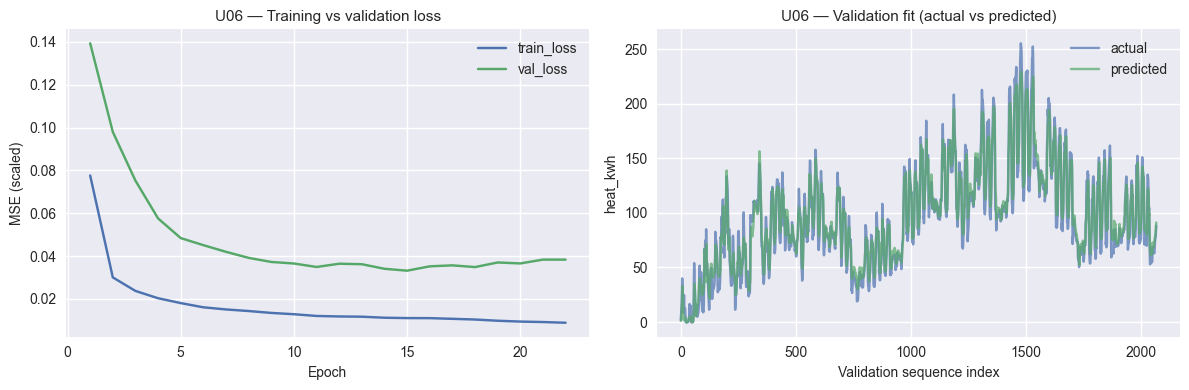

In [ ]:

# Section 7a — Single-building LSTM (setA, temporal only)

single_building_results_df, single_building_details_setA = run_single_building_suite(
    buildings=COHORT_A,
    feature_frames=features_setA,
    split_masks=SPLITS,
    dynamic_cols=SETA_TEMPORAL_FEATURES,
    feature_scalers=temporal_feature_scalers["setA"],
    target_scalers=target_scalers,
    use_static=False,
    fit_verbose=0,
)

print()
print("Single-building LSTM (setA) test metrics:")
print(single_building_results_df.to_string(index=False))

plot_validation_diagnostics(single_building_details_setA, "U06", "U06")


## Section 7b — Single-building LSTM (setB, temporal + static)

In this section we repeat the single-building experiment, but now using **setB** features,
which add the static building/system descriptor block on top of the temporal features.

For each building in the static-complete cohort we will:

- Use the same temporal feature pipeline and sequence builder as in Section 7a.
- Add a broadcast static vector from `setB` as a separate input branch.
- Train `build_lstm_temporal_plus_static(...)` with the same optimisation settings.
- Evaluate on the test split and store the same metrics.

To keep iteration fast, we first run this only for `U06` if needed.
Once the behaviour and metrics look reasonable, you can easily extend the loop to **all buildings in `COHORT_B`** for the overnight run.



=== Single-building LSTM for GEO (temporal + static) ===
Train sequences: 11088, Val: 2066, Test: 8213
Test RMSE=76.293, MAE=13.332, R2=0.0941, WAPE=70.97%

=== Single-building LSTM for ICO (temporal + static) ===
Train sequences: 11159, Val: 2066, Test: 8213
Test RMSE=10.087, MAE=5.897, R2=0.9000, WAPE=20.20%

=== Single-building LSTM for LIB (temporal + static) ===
Train sequences: 11158, Val: 2066, Test: 8213
Test RMSE=9.726, MAE=5.855, R2=0.9754, WAPE=10.19%

=== Single-building LSTM for SOC (temporal + static) ===
Train sequences: 11158, Val: 2066, Test: 8213
Test RMSE=20.058, MAE=11.696, R2=0.9738, WAPE=10.67%

=== Single-building LSTM for STU (temporal + static) ===
Train sequences: 14318, Val: 2066, Test: 62
Test RMSE=30.061, MAE=23.859, R2=0.4851, WAPE=20.38%

=== Single-building LSTM for U01 (temporal + static) ===
Train sequences: 11158, Val: 2066, Test: 8213
Test RMSE=84.803, MAE=53.020, R2=0.0058, WAPE=64.38%

=== Single-building LSTM for U01U02 (temporal + static) ===
Tr

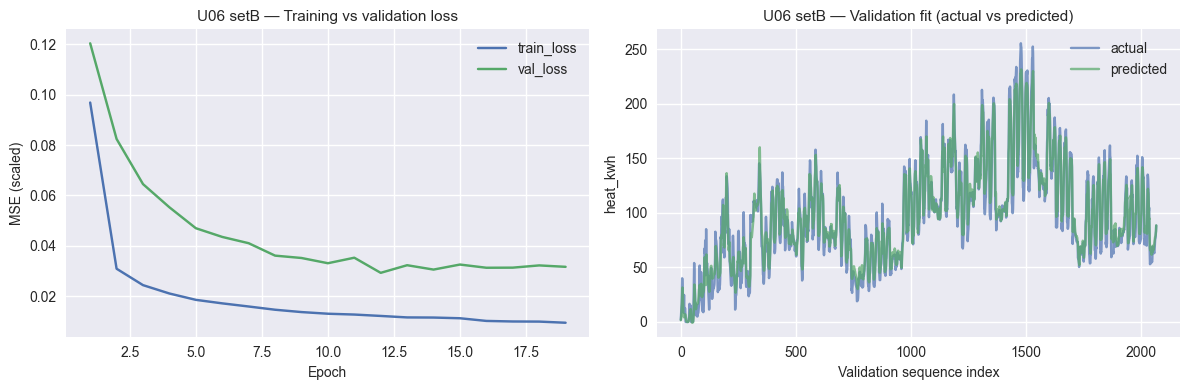

In [11]:
# Section 7b — Single-building LSTM (setB, temporal + static)

single_building_setB_results_df, single_building_details_setB = run_single_building_suite(
    buildings=COHORT_B,
    feature_frames=features_setB,
    split_masks=SPLITS,
    dynamic_cols=SETB_TEMPORAL_FEATURES,
    feature_scalers=temporal_feature_scalers["setB"],
    target_scalers=target_scalers,
    use_static=True,
    fit_verbose=0,
)

print()
print("Single-building LSTM (setB, temporal + static) test metrics:")
print(single_building_setB_results_df.to_string(index=False))

plot_validation_diagnostics(single_building_details_setB, "U06", "U06 setB")


## Section 7c — Global pooled LSTM (setA, temporal only)

In this section we train **one global LSTM model** on pooled sequences from multiple buildings
using the setA feature set (temporal features only).

Key design choices:

- We **keep the per-building scalers** from Section 4 (each building is scaled in its own space).
- We **pool sequences across buildings** for training a single model.
- For evaluation, we keep track of which building each sequence came from so we can:
  - Inverse-transform targets with the correct per-building scaler.
  - Report metrics per building and overall.

To avoid tiny/unstable test windows, we restrict to the **core reporting buildings** `CORE_BUILDINGS_A`.

In [12]:
# Section 7c — Global pooled LSTM (setA, temporal only)

global_setA_results_df, portfolio_metrics_setA, global_counts_setA, model_global_A, history_global_A = run_global_suite(
    buildings=CORE_BUILDINGS_A,
    feature_frames=features_setA,
    split_masks=SPLITS,
    dynamic_cols=SETA_TEMPORAL_FEATURES,
    feature_scalers=temporal_feature_scalers["setA"],
    target_scalers=target_scalers,
    use_static=False,
    fit_verbose=1,
)

print("Global setA pooled sequence counts (per split, per building):")
print("Train:", global_counts_setA["train"])
print("Val:  ", global_counts_setA["val"])
print("Test: ", global_counts_setA["test"])

if portfolio_metrics_setA:
    print()
    print("Global pooled LSTM (setA) — portfolio test metrics:")
    print(
        f"RMSE={portfolio_metrics_setA['rmse']:.3f}, "
        f"MAE={portfolio_metrics_setA['mae']:.3f}, "
        f"R2={portfolio_metrics_setA['r2']:.4f}, "
        f"WAPE={portfolio_metrics_setA['wape_pct']:.2f}%"
    )

print()
print("Global pooled LSTM (setA) — per-building test metrics:")
print(global_setA_results_df.to_string(index=False))


Epoch 1/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 0.0575 - mse: 0.0575 - val_loss: 0.1594 - val_mse: 0.1594 - learning_rate: 0.0010
Epoch 2/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 0.0376 - mse: 0.0376 - val_loss: 0.1204 - val_mse: 0.1204 - learning_rate: 0.0010
Epoch 3/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.0339 - mse: 0.0339 - val_loss: 0.0924 - val_mse: 0.0924 - learning_rate: 0.0010
Epoch 4/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.0310 - mse: 0.0310 - val_loss: 0.1143 - val_mse: 0.1143 - learning_rate: 0.0010
Epoch 5/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 0.0292 - mse: 0.0292 - val_loss: 0.1027 - val_mse: 0.1027 - learning_rate: 0.0010
Epoch 6/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 0.0279 - mse: 0.0279 - val_loss: 0.1082 - val_mse: 0.1082 - learning_rate: 0.0010
Epoch 7/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.0253 - mse: 0.0253 - val_loss: 0.1017 - val_mse: 0.1017 - 

## Section 7d — Global pooled LSTM (setB, temporal + static)

Here we mirror Section 7c, but using **setB** features and the two-branch
`build_lstm_temporal_plus_static(...)` model.

The idea is to:

- Pool temporal sequences across `CORE_BUILDINGS_B`.
- Attach a per-building static descriptor vector to each sequence.
- Train a single global model and then report per-building and portfolio-level metrics.

This section prepares the code so you can trigger a full global run overnight once you are happy with the single-building behaviour.


In [13]:
# Section 7d — Global pooled LSTM (setB, temporal + static)

global_setB_results_df, portfolio_metrics_setB, global_counts_setB, model_global_B, history_global_B = run_global_suite(
    buildings=CORE_BUILDINGS_B,
    feature_frames=features_setB,
    split_masks=SPLITS,
    dynamic_cols=SETB_TEMPORAL_FEATURES,
    feature_scalers=temporal_feature_scalers["setB"],
    target_scalers=target_scalers,
    use_static=True,
    fit_verbose=1,
)

print("Global setB pooled sequence counts (per split, per building):")
print("Train:", global_counts_setB["train"])
print("Val:  ", global_counts_setB["val"])
print("Test: ", global_counts_setB["test"])

if portfolio_metrics_setB:
    print()
    print("Global pooled LSTM (setB) — portfolio test metrics:")
    print(
        f"RMSE={portfolio_metrics_setB['rmse']:.3f}, "
        f"MAE={portfolio_metrics_setB['mae']:.3f}, "
        f"R2={portfolio_metrics_setB['r2']:.4f}, "
        f"WAPE={portfolio_metrics_setB['wape_pct']:.2f}%"
    )

print()
print("Global pooled LSTM (setB, temporal + static) — per-building test metrics:")
print(global_setB_results_df.to_string(index=False))


Epoch 1/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0575 - mse: 0.0575 - val_loss: 0.1297 - val_mse: 0.1297 - learning_rate: 0.0010
Epoch 2/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 0.0374 - mse: 0.0374 - val_loss: 0.1170 - val_mse: 0.1170 - learning_rate: 0.0010
Epoch 3/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 0.0337 - mse: 0.0337 - val_loss: 0.1195 - val_mse: 0.1195 - learning_rate: 0.0010
Epoch 4/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.0310 - mse: 0.0310 - val_loss: 0.0988 - val_mse: 0.0988 - learning_rate: 0.0010
Epoch 5/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 0.0291 - mse: 0.0291 - val_loss: 0.0911 - val_mse: 0.0911 - learning_rate: 0.0010
Epoch 6/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 0.0277 - mse: 0.0277 - val_loss: 0.0907 - val_mse: 0.0907 - learning_rate: 0.0010
Epoch 7/50
2765/2765 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.0263 - mse: 0.0263 - val_loss: 0.0967 - val_mse: 0.0967 - 

## Section 8 — Results overview and comparison plots

In this section we pull together the different result tables:

- Single-building LSTM (setA, temporal only).
- Single-building LSTM (setB, temporal + static).
- Global pooled LSTM (setA).
- Global pooled LSTM (setB).
- Baseline ARX metrics loaded at the start of the notebook.

We will build a **unified comparison table** and a few plots:

- A **bar plot** comparing WAPE per building across models.
- A **portfolio-level bar plot** comparing mean WAPE across models.
- A simple **scatter plot** of baseline vs LSTM performance to visualise gains/losses.


Per-building results overview (first rows):
building baseline_model  baseline_rmse  baseline_mae  baseline_r2  baseline_wape_pct  sb_setA_rmse  sb_setA_mae  sb_setA_r2  sb_setA_wape_pct  sb_setB_rmse  sb_setB_mae  sb_setB_r2  sb_setB_wape_pct  glob_setA_rmse  glob_setA_mae  glob_setA_r2  glob_setA_wape_pct  glob_setB_rmse  glob_setB_mae  glob_setB_r2  glob_setB_wape_pct
     GEO Persistence_1h          7.751         1.487       0.9928              5.914     76.167037    13.569345    0.097089         72.234055     76.293414    13.332380    0.094091         70.972618       75.904610      12.402316      0.103300           66.021584       75.406231      12.255765      0.115037           65.241440
     ICO         ARX_ES          4.150         2.584       0.9828              6.550      7.974563     4.769548    0.937484         16.341560     10.087223     5.896684    0.899972         20.203386        4.259219       2.648987      0.982166            9.076033        4.287154       2.645553    

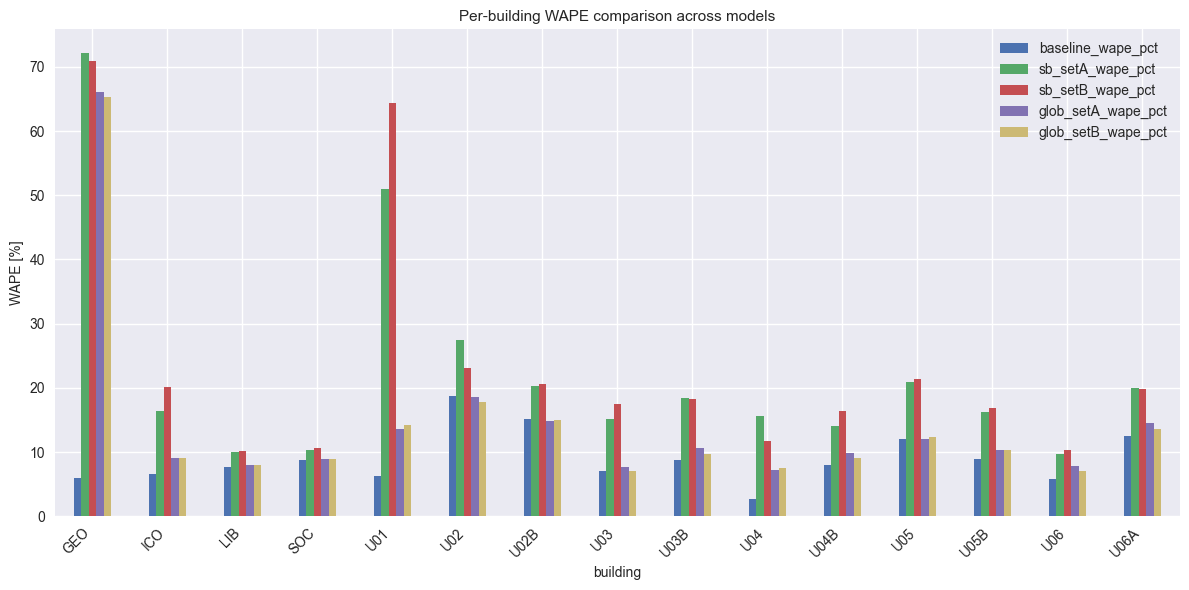

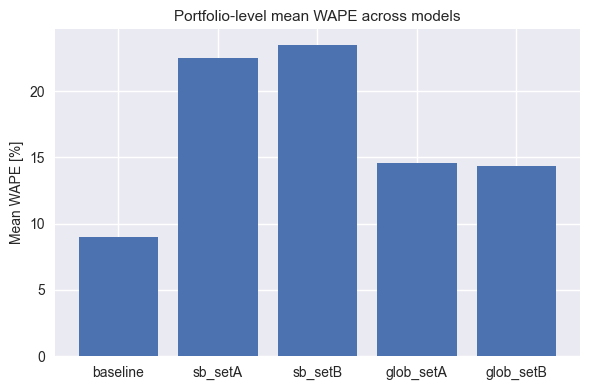

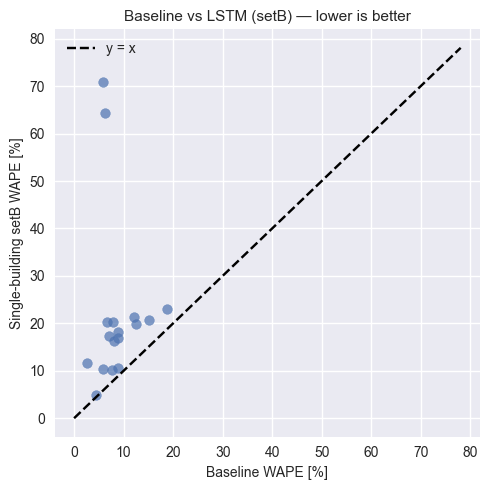


Wilcoxon (baseline WAPE > sb_setB WAPE):
{'n_pairs': 17, 'statistic': 0.0, 'pvalue': 1.0}

Wilcoxon (baseline WAPE > glob_setB WAPE):
{'n_pairs': 15, 'statistic': 11.0, 'pvalue': 0.998687744140625}


In [14]:
# Section 8 — Results overview and comparison plots

from scipy.stats import wilcoxon

# Defensive checks in case some sections have not been run yet
has_sb_A = "single_building_results_df" in globals()
has_sb_B = "single_building_setB_results_df" in globals()
has_glob_A = "global_setA_results_df" in globals()
has_glob_B = "global_setB_results_df" in globals()

# 8a. Build a per-building summary table with baseline + LSTM variants

# Baseline JSON key is "best_model_per_building_by_rmse" in our exported summary.
# Keep a fallback key so this cell remains robust if naming changes later.
baseline_by_building = baseline_summary.get(
    "best_model_per_building_by_rmse",
    baseline_summary.get("per_building_metrics", {}),
)

rows = []

for bldg in ALL_BUILDINGS:
    baseline_metrics = baseline_by_building.get(bldg, {})

    row = {
        "building": bldg,
        "baseline_model": baseline_metrics.get("Model", None),
        "baseline_rmse": baseline_metrics.get("RMSE", None),
        "baseline_mae": baseline_metrics.get("MAE", None),
        "baseline_r2": baseline_metrics.get("R2", None),
        "baseline_wape_pct": baseline_metrics.get("WAPE_pct", None),
    }

    if has_sb_A:
        m = single_building_results_df.set_index("building").to_dict("index").get(bldg)
        if m is not None:
            row.update({
                "sb_setA_rmse": m["rmse"],
                "sb_setA_mae": m["mae"],
                "sb_setA_r2": m["r2"],
                "sb_setA_wape_pct": m["wape_pct"],
            })

    if has_sb_B:
        m = single_building_setB_results_df.set_index("building").to_dict("index").get(bldg)
        if m is not None:
            row.update({
                "sb_setB_rmse": m["rmse"],
                "sb_setB_mae": m["mae"],
                "sb_setB_r2": m["r2"],
                "sb_setB_wape_pct": m["wape_pct"],
            })

    if has_glob_A:
        m = global_setA_results_df.set_index("building").to_dict("index").get(bldg)
        if m is not None:
            row.update({
                "glob_setA_rmse": m["rmse"],
                "glob_setA_mae": m["mae"],
                "glob_setA_r2": m["r2"],
                "glob_setA_wape_pct": m["wape_pct"],
            })

    if has_glob_B:
        m = global_setB_results_df.set_index("building").to_dict("index").get(bldg)
        if m is not None:
            row.update({
                "glob_setB_rmse": m["rmse"],
                "glob_setB_mae": m["mae"],
                "glob_setB_r2": m["r2"],
                "glob_setB_wape_pct": m["wape_pct"],
            })

    rows.append(row)

results_overview_df = pd.DataFrame(rows)
print("Per-building results overview (first rows):")
print(results_overview_df.head().to_string(index=False))

# 8b. WAPE comparison plot per building (core reporting buildings)

plot_buildings = CORE_BUILDINGS_B if has_sb_B else CORE_BUILDINGS_A

subset_cols = [
    "baseline_wape_pct",
]
if has_sb_A:
    subset_cols.append("sb_setA_wape_pct")
if has_sb_B:
    subset_cols.append("sb_setB_wape_pct")
if has_glob_A:
    subset_cols.append("glob_setA_wape_pct")
if has_glob_B:
    subset_cols.append("glob_setB_wape_pct")

plot_df = results_overview_df.loc[results_overview_df["building"].isin(plot_buildings), ["building"] + subset_cols].set_index("building")

plt.figure(figsize=(12, 6))
plot_df.sort_index().plot(kind="bar", ax=plt.gca())
plt.ylabel("WAPE [%]")
plt.title("Per-building WAPE comparison across models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 8c. Portfolio-level mean WAPE bar plot

mean_metrics = {
    "baseline": plot_df["baseline_wape_pct"].mean() if "baseline_wape_pct" in plot_df else np.nan,
}
if "sb_setA_wape_pct" in plot_df:
    mean_metrics["sb_setA"] = plot_df["sb_setA_wape_pct"].mean()
if "sb_setB_wape_pct" in plot_df:
    mean_metrics["sb_setB"] = plot_df["sb_setB_wape_pct"].mean()
if "glob_setA_wape_pct" in plot_df:
    mean_metrics["glob_setA"] = plot_df["glob_setA_wape_pct"].mean()
if "glob_setB_wape_pct" in plot_df:
    mean_metrics["glob_setB"] = plot_df["glob_setB_wape_pct"].mean()

plt.figure(figsize=(6, 4))
plt.bar(mean_metrics.keys(), mean_metrics.values())
plt.ylabel("Mean WAPE [%]")
plt.title("Portfolio-level mean WAPE across models")
plt.tight_layout()
plt.show()

# 8d. Simple baseline vs LSTM scatter (WAPE)

if has_sb_B and not results_overview_df[["baseline_wape_pct", "sb_setB_wape_pct"]].dropna().empty:
    tmp = results_overview_df[["baseline_wape_pct", "sb_setB_wape_pct"]].dropna()

    plt.figure(figsize=(5, 5))
    plt.scatter(tmp["baseline_wape_pct"], tmp["sb_setB_wape_pct"], alpha=0.7)
    lims = [0, max(tmp.max()) * 1.1]
    plt.plot(lims, lims, "k--", label="y = x")
    plt.xlabel("Baseline WAPE [%]")
    plt.ylabel("Single-building setB WAPE [%]")
    plt.title("Baseline vs LSTM (setB) — lower is better")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 8e. Wilcoxon signed-rank tests for WAPE on overlapping buildings

wilcoxon_results = {}

# Baseline vs single-building setB
if has_sb_B:
    tmp = results_overview_df[["baseline_wape_pct", "sb_setB_wape_pct"]].dropna()
    n_pairs = len(tmp)
    if n_pairs >= 5:
        stat, pvalue = wilcoxon(tmp["baseline_wape_pct"], tmp["sb_setB_wape_pct"], alternative="greater")
        wilcoxon_results["baseline_vs_sb_setB"] = {
            "n_pairs": int(n_pairs),
            "statistic": float(stat),
            "pvalue": float(pvalue),
        }
        print("\nWilcoxon (baseline WAPE > sb_setB WAPE):")
        print(wilcoxon_results["baseline_vs_sb_setB"])
    else:
        print(f"\n[INFO] Not enough paired buildings for baseline vs sb_setB Wilcoxon (n={n_pairs}, need >=5).")

# Baseline vs global setB
if has_glob_B:
    tmp = results_overview_df[["baseline_wape_pct", "glob_setB_wape_pct"]].dropna()
    n_pairs = len(tmp)
    if n_pairs >= 5:
        stat, pvalue = wilcoxon(tmp["baseline_wape_pct"], tmp["glob_setB_wape_pct"], alternative="greater")
        wilcoxon_results["baseline_vs_glob_setB"] = {
            "n_pairs": int(n_pairs),
            "statistic": float(stat),
            "pvalue": float(pvalue),
        }
        print("\nWilcoxon (baseline WAPE > glob_setB WAPE):")
        print(wilcoxon_results["baseline_vs_glob_setB"])
    else:
        print(f"\n[INFO] Not enough paired buildings for baseline vs glob_setB Wilcoxon (n={n_pairs}, need >=5).")


## Section 9 — Explainability: permutation importance and simple scenarios

To keep explainability tractable and model-agnostic, we will focus on:

- **Permutation Feature Importance (PFI)** on validation data for a small subset of configurations
  (e.g. `U06` single-building setA and setB, and optionally the global setB model).
- A few **simple scenario plots** where we nudge selected temporal inputs for `U06`
  (for example outside temperature) and see how the prediction curve responds.

This keeps the runtime reasonable while still giving clear, thesis-ready figures
about which temporal signals and static descriptor families are driving the predictions.


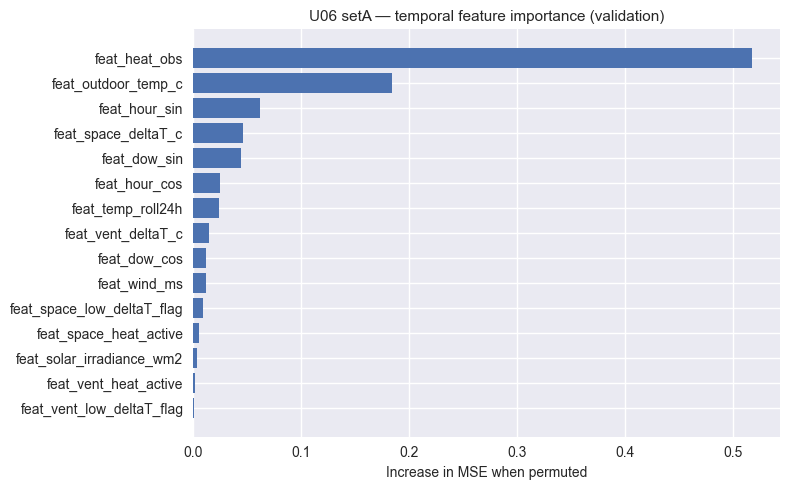

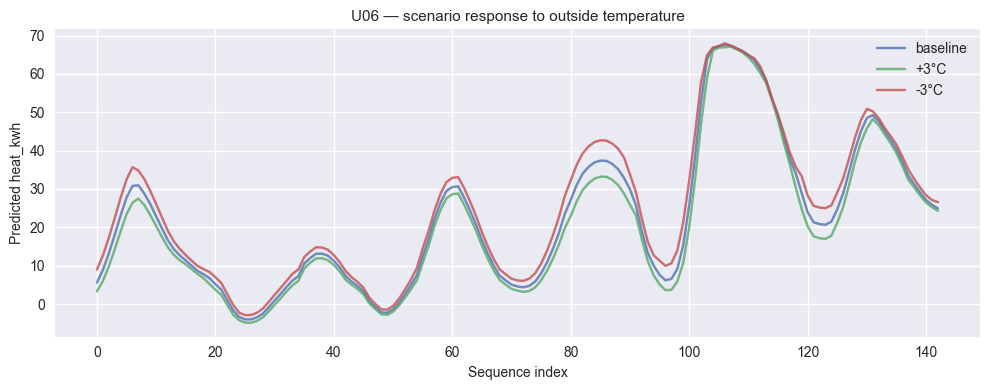

In [15]:
# Section 9 — Explainability helpers (permutation importance + scenarios)

from typing import Sequence


def permutation_importance_1d(model, X_val: np.ndarray, y_val: np.ndarray, metric, n_repeats: int = 5):
    """Simple permutation importance for 2D inputs (n_samples, n_features)."""
    base_pred = model.predict(X_val, verbose=0).reshape(-1)
    base_score = metric(y_val, base_pred)

    importances = []
    n_features = X_val.shape[1]

    for j in range(n_features):
        scores = []
        X_perm = X_val.copy()
        for _ in range(n_repeats):
            perm = np.random.permutation(X_val.shape[0])
            X_perm[:, j] = X_val[perm, j]
            pred_perm = model.predict(X_perm, verbose=0).reshape(-1)
            scores.append(metric(y_val, pred_perm))
        importances.append(np.mean(scores) - base_score)

    return np.array(importances), base_score


def permutation_importance_temporal(
    model,
    X_val: np.ndarray,
    y_val: np.ndarray,
    feature_names: Sequence[str],
    n_repeats: int = 3,
):
    """Permutation importance for temporal inputs (n_samples, n_timesteps, n_features)."""
    base_pred = model.predict(X_val, verbose=0).reshape(-1)
    base_score = mean_squared_error(y_val, base_pred)

    n_features = X_val.shape[2]
    importances = []

    for j in range(n_features):
        scores = []
        X_perm = X_val.copy()
        for _ in range(n_repeats):
            perm = np.random.permutation(X_val.shape[0])
            X_perm[:, :, j] = X_val[perm, :, j]
            pred_perm = model.predict(X_perm, verbose=0).reshape(-1)
            scores.append(mean_squared_error(y_val, pred_perm))
        importances.append(np.mean(scores) - base_score)

    importances = np.array(importances)
    order = np.argsort(importances)[::-1]
    sorted_names = [feature_names[i] for i in order]
    sorted_importances = importances[order]

    return sorted_names, sorted_importances, base_score


if "U06" in ALL_BUILDINGS:
    bldg = "U06"
    df_A = features_setA[bldg].copy()
    masks = SPLITS[bldg]
    dynamic_cols = SETA_TEMPORAL_FEATURES.copy()

    X_all = temporal_feature_scalers["setA"][bldg].transform(df_A[dynamic_cols].values)
    y_all = target_scalers[bldg].transform(df_A[["heat_kwh"]].values)

    df_scaled = df_A.copy()
    df_scaled[dynamic_cols] = X_all
    df_scaled["heat_kwh_scaled"] = y_all

    X_val, y_val = build_sequences(
        df=df_scaled,
        dynamic_cols=dynamic_cols,
        target_col="heat_kwh_scaled",
        split_mask=masks["val"],
        lookback=CONFIG["LOOKBACK_HOURS"],
    )

    if X_val.shape[0] > 0:
        model_u06_A = build_lstm_temporal_only(
            n_timesteps=CONFIG["LOOKBACK_HOURS"],
            n_features=len(dynamic_cols),
        )
        model_u06_A.fit(
            X_val,
            y_val,
            epochs=max(5, CONFIG["EPOCHS"] // 2),
            batch_size=CONFIG["BATCH_SIZE"],
            verbose=0,
        )

        names_A, importances_A, base_mse_A = permutation_importance_temporal(
            model_u06_A,
            X_val,
            y_val,
            feature_names=dynamic_cols,
            n_repeats=3,
        )

        top_k = min(15, len(names_A))
        plt.figure(figsize=(8, 5))
        plt.barh(range(top_k), importances_A[:top_k][::-1])
        plt.yticks(range(top_k), names_A[:top_k][::-1])
        plt.xlabel("Increase in MSE when permuted")
        plt.title("U06 setA — temporal feature importance (validation)")
        plt.tight_layout()
        plt.show()

if "U06" in ALL_BUILDINGS:
    bldg = "U06"
    df = features_setA[bldg].copy()
    masks = SPLITS[bldg]
    dynamic_cols = SETA_TEMPORAL_FEATURES.copy()

    df_val = df.loc[masks["val"]].copy().iloc[: 24 * 7]

    if not df_val.empty:
        X_all = temporal_feature_scalers["setA"][bldg].transform(df_val[dynamic_cols].values)
        y_all = target_scalers[bldg].transform(df_val[["heat_kwh"]].values)

        df_val_scaled = df_val.copy()
        df_val_scaled[dynamic_cols] = X_all
        df_val_scaled["heat_kwh_scaled"] = y_all

        X_seq, y_seq = build_sequences(
            df=df_val_scaled,
            dynamic_cols=dynamic_cols,
            target_col="heat_kwh_scaled",
            split_mask=np.ones(len(df_val_scaled), dtype=bool),
            lookback=CONFIG["LOOKBACK_HOURS"],
        )

        if X_seq.shape[0] > 0:
            model_u06_scn = build_lstm_temporal_only(
                n_timesteps=CONFIG["LOOKBACK_HOURS"],
                n_features=len(dynamic_cols),
            )
            model_u06_scn.fit(
                X_seq,
                y_seq,
                epochs=max(5, CONFIG["EPOCHS"] // 2),
                batch_size=CONFIG["BATCH_SIZE"],
                verbose=0,
            )

            temp_cols = [c for c in dynamic_cols if "temp" in c.lower() or "outdoor" in c.lower()]
            if temp_cols:
                temp_col = temp_cols[0]
                scaler_temp = temporal_feature_scalers["setA"][bldg]
                j = dynamic_cols.index(temp_col)

                y_pred_base_scaled = model_u06_scn.predict(X_seq, verbose=0).reshape(-1, 1)
                y_pred_base = target_scalers[bldg].inverse_transform(y_pred_base_scaled).flatten()

                X_warm = X_seq.copy()
                X_warm[:, :, j] += 3.0 / scaler_temp.scale_[j]
                y_pred_warm = target_scalers[bldg].inverse_transform(model_u06_scn.predict(X_warm, verbose=0).reshape(-1, 1)).flatten()

                X_cold = X_seq.copy()
                X_cold[:, :, j] -= 3.0 / scaler_temp.scale_[j]
                y_pred_cold = target_scalers[bldg].inverse_transform(model_u06_scn.predict(X_cold, verbose=0).reshape(-1, 1)).flatten()

                plt.figure(figsize=(10, 4))
                plt.plot(y_pred_base, label="baseline", alpha=0.8)
                plt.plot(y_pred_warm, label="+3°C", alpha=0.8)
                plt.plot(y_pred_cold, label="-3°C", alpha=0.8)
                plt.xlabel("Sequence index")
                plt.ylabel("Predicted heat_kwh")
                plt.title("U06 — scenario response to outside temperature")
                plt.legend()
                plt.tight_layout()
                plt.show()


## Section 10 — Export and validation gate

Finally, we export the key results and run a few sanity checks before
accepting the experiment run:

- Save per-building and global result tables as CSV/JSON in the `results` folder.
- Optionally save model weights for the global models.
- Run a few **assertions** to catch obviously broken runs (e.g. empty tables,
  NaN metrics, wildly out-of-range R²).

In [16]:
# Section 10 — Export and validation gate

from pathlib import Path

RESULTS_DIR = Path(PROJECT_ROOT) / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 10a. Export result tables

if "single_building_results_df" in globals():
    single_building_results_df.to_csv(RESULTS_DIR / "lstm_single_setA_results.csv", index=False)
if "single_building_setB_results_df" in globals():
    single_building_setB_results_df.to_csv(RESULTS_DIR / "lstm_single_setB_results.csv", index=False)
if "global_setA_results_df" in globals():
    global_setA_results_df.to_csv(RESULTS_DIR / "lstm_global_setA_results.csv", index=False)
if "global_setB_results_df" in globals():
    global_setB_results_df.to_csv(RESULTS_DIR / "lstm_global_setB_results.csv", index=False)

results_overview_path = RESULTS_DIR / "lstm_results_overview.csv"
results_overview_df.to_csv(results_overview_path, index=False)
print(f"Saved unified results overview to {results_overview_path}")

# 10b. Optionally save global models (if they exist)

if "model_global_A" in globals():
    model_global_A.save(RESULTS_DIR / "model_global_setA.keras")
if "model_global_B" in globals():
    model_global_B.save(RESULTS_DIR / "model_global_setB.keras")

# 10c. Simple validation gate

assert not results_overview_df.empty, "[VALIDATION] Results overview is empty. Did the models run?"

# Basic range checks for WAPE and R2 on buildings that have LSTM results
check_df = results_overview_df.dropna(subset=["baseline_wape_pct"])

# Only validate rows where the metric exists (ignore NaN for non-overlapping variants)
if "sb_setB_wape_pct" in check_df.columns:
    s = check_df["sb_setB_wape_pct"].dropna()
    if len(s) > 0:
        assert (s > 0).all(), "[VALIDATION] Non-positive WAPE encountered for setB."

if "sb_setB_r2" in check_df.columns:
    s = check_df["sb_setB_r2"].dropna()
    if len(s) > 0:
        assert (s > -1.0).all(), "[VALIDATION] R2 below -1 detected for setB."

print("Validation gate checks passed.")


Saved unified results overview to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/lstm_results_overview.csv
Validation gate checks passed.


## Section 11 — Revised fair experiment setup (direct `M0-M4` inertia workflow)

This section defines the thesis-facing revised workflow around five explicit modes:

- `M0`: base temporal core
- `M1`: `M0 +` weather-memory
- `M2`: `M0 +` system / inertia block
- `M3`: full lean temporal model (`M0 + M1 + M2`)
- `M4`: `M3 +` lean static descriptor block

The revised path uses one consistent evaluator for both **single-building** and **global pooled** runs, stores `mode` as a first-class field in the run log, and prepares the objects needed for direct export and building-level gain diagnostics.


In [17]:
# Section 11a — Revised config and mode helpers

from typing import Dict, List, Optional, Tuple

from scipy.stats import wilcoxon, t

REVISED_SEEDS = [42, 52, 62, 72, 82]
REVISED_MODE_ORDER = ["M0", "M1", "M2", "M3", "M4"]
REVISED_SCOPE_ORDER = ["single", "global"]
MATCHED_COHORT = [b for b in COHORT_B if b in CORE_BUILDINGS_B]
COLDSTART_HORIZONS = [24, 72, 168, 336]
REVISED_TRACE_SEED = REVISED_SEEDS[0]

REVISED_MAIN_TARGET = "heat_kwh"
REVISED_NORMALIZED_TARGET = "heat_kwh_m2"
RUN_NORMALIZED_SENSITIVITY = True
REVISED_NORMALIZED_SEEDS = [REVISED_TRACE_SEED]

REVISED_CONFIG = {
    "LOOKBACK_HOURS": CONFIG["LOOKBACK_HOURS"],
    "BATCH_SIZE": CONFIG["BATCH_SIZE"],
    "EPOCHS": CONFIG["EPOCHS"],
    "LEARNING_RATE": CONFIG["LEARNING_RATE"],
    "EARLY_STOPPING_PATIENCE": CONFIG["EARLY_STOPPING_PATIENCE"],
}

BUILDING_STATIC_FEATURES_FILE = DATA_DIR / "clean" / "building_static_features.csv"


def target_scaled_name(target_col: str) -> str:
    return f"{target_col}_scaled"


def set_all_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def mode_uses_static(mode: str) -> bool:
    return mode == "M4"


def feature_set_for_mode(mode: str) -> str:
    return "setB" if mode_uses_static(mode) else "setA"


def infer_feature_groups(dynamic_cols: List[str]) -> Dict[str, List[str]]:
    return {
        "base_core": [c for c in dynamic_cols if c in set(LSTM_BASE_TEMPORAL_FEATURES)],
        "weather_memory": [c for c in dynamic_cols if c in set(LSTM_WEATHER_MEMORY_FEATURES)],
        "system_dynamic": [c for c in dynamic_cols if c in set(LSTM_SYSTEM_DYNAMIC_FEATURES)],
        "calendar": [c for c in dynamic_cols if c in set(EXPERIMENT_FEATURE_GROUPS["calendar"])],
        "static_building": STATIC_FEATURES.copy(),
    }


def select_dynamic_cols_by_mode(dynamic_cols: List[str], mode: str) -> List[str]:
    """Build lean feature subsets for inertia ablation modes."""
    g = infer_feature_groups(dynamic_cols)

    if mode not in set(REVISED_MODE_ORDER):
        raise ValueError(f"Unknown mode: {mode}")

    selected = list(g["base_core"])
    if mode in {"M1", "M3", "M4"}:
        selected += g["weather_memory"]
    if mode in {"M2", "M3", "M4"}:
        selected += g["system_dynamic"]

    selected = _unique_keep_order(selected)
    return [c for c in dynamic_cols if c in set(selected)]


def compute_regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return _compute_basic_metrics(y_true, y_pred)


def compute_horizon_wape(y_true: np.ndarray, y_pred: np.ndarray, horizons: List[int]) -> Dict[str, float]:
    out = {}
    n = len(y_true)
    for h in horizons:
        k = min(h, n)
        if k <= 0:
            out[f"wape_{h}h"] = np.nan
            continue
        yt = y_true[:k]
        yp = y_pred[:k]
        denom = float(np.sum(np.abs(yt)))
        out[f"wape_{h}h"] = float(100.0 * np.sum(np.abs(yt - yp)) / denom) if denom > 0 else np.nan
    return out


def target_is_available(target_col: str, buildings: List[str]) -> bool:
    return all(
        target_col in features_setA[b].columns and target_col in features_setB[b].columns
        for b in buildings
    )


def building_has_valid_normalized_target(building: str) -> bool:
    df = features_setB[building]
    if REVISED_NORMALIZED_TARGET not in df.columns:
        return False
    area_series = pd.to_numeric(df.get("stat_heated_area_m2"), errors="coerce").dropna()
    if area_series.empty:
        return False
    area_val = float(area_series.iloc[0])
    if not np.isfinite(area_val) or area_val <= 0:
        return False
    target_train = pd.to_numeric(df.loc[SPLITS[building]["train"], REVISED_NORMALIZED_TARGET], errors="coerce")
    target_test = pd.to_numeric(df.loc[SPLITS[building]["test"], REVISED_NORMALIZED_TARGET], errors="coerce")
    return target_train.notna().sum() > REVISED_CONFIG["LOOKBACK_HOURS"] and target_test.notna().sum() > 0


def fit_revised_target_scalers(target_col: str, buildings: List[str]) -> Tuple[Dict[str, StandardScaler], List[str]]:
    scalers = {}
    missing = []
    for bldg in buildings:
        df = features_setA[bldg] if target_col in features_setA[bldg].columns else features_setB[bldg]
        if target_col not in df.columns:
            missing.append(bldg)
            continue
        y_train = pd.to_numeric(df.loc[SPLITS[bldg]["train"], target_col], errors="coerce").dropna().to_numpy().reshape(-1, 1)
        if len(y_train) == 0:
            missing.append(bldg)
            continue
        scaler = StandardScaler()
        scaler.fit(y_train)
        scalers[bldg] = scaler
    return scalers, missing


MATCHED_COHORT_NORMALIZED = []
if RUN_NORMALIZED_SENSITIVITY and target_is_available(REVISED_NORMALIZED_TARGET, MATCHED_COHORT):
    MATCHED_COHORT_NORMALIZED = [b for b in MATCHED_COHORT if building_has_valid_normalized_target(b)]
elif RUN_NORMALIZED_SENSITIVITY:
    print(
        f"[WARN] {REVISED_NORMALIZED_TARGET} is not available in the exported feature tables yet. "
        "Rerun the export cell in 03_feature_engineering_10032026.ipynb before executing the normalized sensitivity."
    )

REVISED_TARGET_BUILDINGS = {
    REVISED_MAIN_TARGET: MATCHED_COHORT.copy(),
}
if RUN_NORMALIZED_SENSITIVITY:
    REVISED_TARGET_BUILDINGS[REVISED_NORMALIZED_TARGET] = MATCHED_COHORT_NORMALIZED.copy()

REVISED_TARGET_SCALERS = {}
for target_col, buildings in REVISED_TARGET_BUILDINGS.items():
    if not buildings:
        REVISED_TARGET_SCALERS[target_col] = {}
        continue
    scalers, missing = fit_revised_target_scalers(target_col, buildings)
    REVISED_TARGET_SCALERS[target_col] = scalers
    if missing:
        print(f"[WARN] Target scaler not fitted for {target_col} in buildings: {missing}")

print("Revised seeds:", REVISED_SEEDS)
print("Matched fair cohort (direct M0-M4):", MATCHED_COHORT)
print("Normalized-target cohort:", MATCHED_COHORT_NORMALIZED)
print("Base temporal block:", LSTM_BASE_TEMPORAL_FEATURES)
print("Weather-memory block:", LSTM_WEATHER_MEMORY_FEATURES)
print("System-dynamic block:", LSTM_SYSTEM_DYNAMIC_FEATURES)
print("Static block (M4 only):", STATIC_FEATURES)
print("Main revised target:", REVISED_MAIN_TARGET)
print("Normalized sensitivity target:", REVISED_NORMALIZED_TARGET)



Revised seeds: [42, 52, 62, 72, 82]
Matched fair cohort (direct M0-M4): ['GEO', 'ICO', 'LIB', 'SOC', 'U01', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']
Normalized-target cohort: ['GEO', 'LIB', 'SOC', 'U01', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U05', 'U06', 'U06A']
Base temporal block: ['feat_heat_obs', 'feat_outdoor_temp_c', 'feat_wind_ms', 'feat_solar_irradiance_wm2', 'feat_hour_sin', 'feat_hour_cos', 'feat_dow_sin', 'feat_dow_cos']
Weather-memory block: ['feat_temp_roll24h']
System-dynamic block: ['feat_space_heat_active', 'feat_space_deltaT_c', 'feat_space_low_deltaT_flag', 'feat_vent_heat_active', 'feat_vent_deltaT_c', 'feat_vent_low_deltaT_flag']
Static block (M4 only): ['stat_heated_area_m2', 'stat_usage_non_res_share_of_heated', 'stat_building_age_years', 'stat_n_points', 'stat_n_heat_points', 'stat_n_vent_points', 'stat_n_dhw_points', 'stat_vent_class_basic', 'stat_vent_class_none', 'stat_vent_class_rich', 'stat_ventilation_has_heat_recovery', 'e

In [18]:
# Section 11b — Revised preprocessing and model-fit helpers


def build_static_feature_vector(df_B: pd.DataFrame) -> np.ndarray:
    return _build_static_vector(df_B)


def get_revised_target_scaler(building: str, target_col: str) -> StandardScaler:
    scaler = REVISED_TARGET_SCALERS.get(target_col, {}).get(building)
    if scaler is None:
        raise KeyError(f"Missing target scaler for building={building}, target={target_col}")
    return scaler


def prepare_scaled_frame(
    df: pd.DataFrame,
    building: str,
    feature_set: str,
    dynamic_cols: Optional[List[str]] = None,
    target_col: str = REVISED_MAIN_TARGET,
) -> pd.DataFrame:
    if dynamic_cols is None:
        dynamic_cols = TEMPORAL_FEATURES_BY_SET[feature_set]

    out = df.copy()
    out[list(dynamic_cols)] = temporal_feature_scalers[feature_set][building].transform(df[list(dynamic_cols)].values)

    scaled_target_col = target_scaled_name(target_col)
    out[scaled_target_col] = np.nan
    valid_target_mask = df[target_col].notna()
    if valid_target_mask.any():
        scaler_y = get_revised_target_scaler(building, target_col)
        out.loc[valid_target_mask, scaled_target_col] = scaler_y.transform(df.loc[valid_target_mask, [target_col]].values).flatten()
    return out


def inverse_target_for_building(building: str, target_col: str, values: np.ndarray) -> np.ndarray:
    scaler_y = get_revised_target_scaler(building, target_col)
    return scaler_y.inverse_transform(np.asarray(values, dtype="float32").reshape(-1, 1)).flatten()


def build_sequences_with_target_index(
    df: pd.DataFrame,
    dynamic_cols: List[str],
    target_col: str,
    split_mask: pd.Series,
    lookback: int,
) -> Tuple[np.ndarray, np.ndarray, List[pd.Timestamp]]:
    mask = np.asarray(split_mask, dtype=bool)
    X_list, y_list, ts_list = [], [], []

    for end_idx in range(lookback, len(df)):
        if not mask[end_idx]:
            continue
        start_idx = end_idx - lookback
        if not mask[start_idx:end_idx].all():
            continue

        window = df.iloc[start_idx:end_idx]
        target_val = df.iloc[end_idx][target_col]
        if window[dynamic_cols].isna().any().any() or pd.isna(target_val):
            continue

        X_list.append(window[dynamic_cols].values.astype("float32"))
        y_list.append(float(target_val))
        ts_list.append(pd.Timestamp(df.index[end_idx]))

    if not X_list:
        return (
            np.empty((0, lookback, len(dynamic_cols)), dtype="float32"),
            np.empty((0,), dtype="float32"),
            [],
        )

    return np.stack(X_list, axis=0), np.array(y_list, dtype="float32"), ts_list


def build_model_for_mode(mode: str, n_timesteps: int, n_dynamic_features: int, n_static_features: int = 0):
    if mode_uses_static(mode):
        return build_lstm_temporal_plus_static(
            n_timesteps=n_timesteps,
            n_dynamic=n_dynamic_features,
            n_static_features=n_static_features,
        )
    return build_lstm_temporal_only(n_timesteps, n_dynamic_features)


def fit_model_for_mode(
    mode: str,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_train_static: Optional[np.ndarray] = None,
    X_val_static: Optional[np.ndarray] = None,
):
    model = build_model_for_mode(
        mode=mode,
        n_timesteps=REVISED_CONFIG["LOOKBACK_HOURS"],
        n_dynamic_features=X_train.shape[2],
        n_static_features=0 if X_train_static is None else X_train_static.shape[1],
    )

    callbacks = _make_lstm_callbacks(REVISED_CONFIG)

    if mode_uses_static(mode):
        model.fit(
            [X_train, X_train_static],
            y_train,
            validation_data=([X_val, X_val_static], y_val),
            epochs=REVISED_CONFIG["EPOCHS"],
            batch_size=REVISED_CONFIG["BATCH_SIZE"],
            verbose=0,
            callbacks=callbacks,
        )
    else:
        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=REVISED_CONFIG["EPOCHS"],
            batch_size=REVISED_CONFIG["BATCH_SIZE"],
            verbose=0,
            callbacks=callbacks,
        )

    return model



In [19]:
# Section 11c — Revised single / global runner helpers


def run_single_building_once(
    building: str,
    mode: str,
    seed: int,
    strict_cold_start: bool = False,
    target_col: str = REVISED_MAIN_TARGET,
) -> Dict[str, float]:
    """Consistent evaluator for one building / one seed / one mode."""
    set_all_seeds(seed)

    use_static = mode_uses_static(mode)
    feature_set = feature_set_for_mode(mode)
    df = features_setB[building].copy() if use_static else features_setA[building].copy()
    masks = SPLITS[building]

    dynamic_cols_all = TEMPORAL_FEATURES_BY_SET[feature_set].copy()
    if strict_cold_start:
        dynamic_cols_all = [c for c in dynamic_cols_all if c != "feat_heat_obs"]

    dynamic_cols = select_dynamic_cols_by_mode(dynamic_cols_all, mode)
    df_scaled = prepare_scaled_frame(df, building, feature_set, dynamic_cols_all, target_col=target_col)
    target_scaled_col = target_scaled_name(target_col)

    X_train, y_train = build_sequences(df_scaled, dynamic_cols, target_scaled_col, masks["train"], REVISED_CONFIG["LOOKBACK_HOURS"])
    X_val, y_val = build_sequences(df_scaled, dynamic_cols, target_scaled_col, masks["val"], REVISED_CONFIG["LOOKBACK_HOURS"])
    X_test, y_test = build_sequences(df_scaled, dynamic_cols, target_scaled_col, masks["test"], REVISED_CONFIG["LOOKBACK_HOURS"])

    n_train, n_val, n_test = int(X_train.shape[0]), int(X_val.shape[0]), int(X_test.shape[0])
    base_row = {
        "building": building,
        "feature_set": feature_set,
        "mode": mode,
        "target_variant": target_col,
        "use_static": bool(use_static),
        "strict_cold_start": bool(strict_cold_start),
        "seed": int(seed),
        "n_dynamic_features": int(len(dynamic_cols)),
        "n_static_features": int(len(STATIC_FEATURES)) if use_static else 0,
        "n_train_seq": n_train,
        "n_val_seq": n_val,
        "n_test_seq": n_test,
    }

    if n_train == 0 or n_val == 0 or n_test == 0:
        base_row["status"] = "skipped"
        return base_row

    X_train_static = X_val_static = X_test_static = None
    if use_static:
        static_vec = build_static_feature_vector(features_setB[building])
        X_train_static = np.repeat(static_vec, repeats=n_train, axis=0)
        X_val_static = np.repeat(static_vec, repeats=n_val, axis=0)
        X_test_static = np.repeat(static_vec, repeats=n_test, axis=0)

    model = fit_model_for_mode(
        mode=mode,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_train_static=X_train_static,
        X_val_static=X_val_static,
    )

    y_pred_scaled = model.predict([X_test, X_test_static], verbose=0).reshape(-1, 1) if use_static else model.predict(X_test, verbose=0).reshape(-1, 1)

    y_true = inverse_target_for_building(building, target_col, y_test)
    y_pred = inverse_target_for_building(building, target_col, y_pred_scaled)

    out = base_row.copy()
    out["status"] = "ok"
    out.update(compute_regression_metrics(y_true, y_pred))
    out.update(compute_horizon_wape(y_true, y_pred, COLDSTART_HORIZONS))
    return out


def run_global_mode_once(
    buildings: List[str],
    mode: str,
    seed: int,
    strict_cold_start: bool = False,
    target_col: str = REVISED_MAIN_TARGET,
) -> pd.DataFrame:
    set_all_seeds(seed)

    use_static = mode_uses_static(mode)
    feature_set = feature_set_for_mode(mode)
    dynamic_cols_all = TEMPORAL_FEATURES_BY_SET[feature_set].copy()
    if strict_cold_start:
        dynamic_cols_all = [c for c in dynamic_cols_all if c != "feat_heat_obs"]
    selected_cols = select_dynamic_cols_by_mode(dynamic_cols_all, mode)
    scaled_target_col = target_scaled_name(target_col)

    X_train_list, y_train_list = [], []
    X_val_list, y_val_list = [], []
    X_test_list, y_test_list, b_test_list = [], [], []
    X_train_static_list, X_val_static_list, X_test_static_list = [], [], []
    per_building_counts = {}
    skipped_rows = []

    for bldg in buildings:
        df = features_setB[bldg].copy() if use_static else features_setA[bldg].copy()
        masks = SPLITS[bldg]
        df_scaled = prepare_scaled_frame(df, bldg, feature_set, dynamic_cols_all, target_col=target_col)

        X_tr, y_tr = build_sequences(df_scaled, selected_cols, scaled_target_col, masks["train"], REVISED_CONFIG["LOOKBACK_HOURS"])
        X_va, y_va = build_sequences(df_scaled, selected_cols, scaled_target_col, masks["val"], REVISED_CONFIG["LOOKBACK_HOURS"])
        X_te, y_te = build_sequences(df_scaled, selected_cols, scaled_target_col, masks["test"], REVISED_CONFIG["LOOKBACK_HOURS"])

        n_tr, n_va, n_te = int(X_tr.shape[0]), int(X_va.shape[0]), int(X_te.shape[0])
        per_building_counts[bldg] = {"n_train_seq": n_tr, "n_val_seq": n_va, "n_test_seq": n_te}

        if n_tr == 0 or n_va == 0 or n_te == 0:
            skipped_rows.append({
                "building": bldg,
                "feature_set": feature_set,
                "mode": mode,
                "target_variant": target_col,
                "use_static": bool(use_static),
                "strict_cold_start": bool(strict_cold_start),
                "seed": int(seed),
                "n_dynamic_features": int(len(selected_cols)),
                "n_static_features": int(len(STATIC_FEATURES)) if use_static else 0,
                "n_train_seq": n_tr,
                "n_val_seq": n_va,
                "n_test_seq": n_te,
                "n_train_seq_pooled": 0,
                "n_val_seq_pooled": 0,
                "n_test_seq_pooled": 0,
                "status": "skipped",
            })
            continue

        X_train_list.append(X_tr)
        y_train_list.append(y_tr)
        X_val_list.append(X_va)
        y_val_list.append(y_va)
        X_test_list.append(X_te)
        y_test_list.append(y_te)
        b_test_list.extend([bldg] * n_te)

        if use_static:
            static_vec = build_static_feature_vector(features_setB[bldg])
            X_train_static_list.append(np.repeat(static_vec, repeats=n_tr, axis=0))
            X_val_static_list.append(np.repeat(static_vec, repeats=n_va, axis=0))
            X_test_static_list.append(np.repeat(static_vec, repeats=n_te, axis=0))

    if not X_train_list:
        return pd.DataFrame(skipped_rows)

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_val = np.concatenate(X_val_list, axis=0)
    y_val = np.concatenate(y_val_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    X_train_static = X_val_static = X_test_static = None
    if use_static:
        X_train_static = np.concatenate(X_train_static_list, axis=0)
        X_val_static = np.concatenate(X_val_static_list, axis=0)
        X_test_static = np.concatenate(X_test_static_list, axis=0)

    model = fit_model_for_mode(mode, X_train, y_train, X_val, y_val, X_train_static, X_val_static)
    y_pred_scaled = model.predict([X_test, X_test_static], verbose=0).reshape(-1, 1) if use_static else model.predict(X_test, verbose=0).reshape(-1, 1)

    rows = []
    pooled_counts = {
        "n_train_seq_pooled": int(X_train.shape[0]),
        "n_val_seq_pooled": int(X_val.shape[0]),
        "n_test_seq_pooled": int(X_test.shape[0]),
    }

    for bldg in sorted(set(b_test_list)):
        idx = [i for i, b in enumerate(b_test_list) if b == bldg]
        y_true_b = inverse_target_for_building(bldg, target_col, y_test[idx])
        y_pred_b = inverse_target_for_building(bldg, target_col, y_pred_scaled[idx])

        row = {
            "building": bldg,
            "feature_set": feature_set,
            "mode": mode,
            "target_variant": target_col,
            "use_static": bool(use_static),
            "strict_cold_start": bool(strict_cold_start),
            "seed": int(seed),
            "n_dynamic_features": int(len(selected_cols)),
            "n_static_features": int(len(STATIC_FEATURES)) if use_static else 0,
            "status": "ok",
        }
        row.update(per_building_counts[bldg])
        row.update(pooled_counts)
        row.update(compute_regression_metrics(y_true_b, y_pred_b))
        row.update(compute_horizon_wape(y_true_b, y_pred_b, COLDSTART_HORIZONS))
        rows.append(row)

    rows.extend(skipped_rows)
    return pd.DataFrame(rows)


def collect_global_test_predictions(
    buildings: List[str],
    mode: str,
    seed: int,
    target_col: str = REVISED_MAIN_TARGET,
) -> pd.DataFrame:
    """Train one pooled global model and return per-sequence test predictions for diagnostics."""
    set_all_seeds(seed)

    use_static = mode_uses_static(mode)
    feature_set = feature_set_for_mode(mode)
    dynamic_cols_all = TEMPORAL_FEATURES_BY_SET[feature_set].copy()
    selected_cols = select_dynamic_cols_by_mode(dynamic_cols_all, mode)
    scaled_target_col = target_scaled_name(target_col)

    X_train_list, y_train_list = [], []
    X_val_list, y_val_list = [], []
    X_test_list, y_test_list = [], []
    X_train_static_list, X_val_static_list, X_test_static_list = [], [], []
    test_meta_frames = []

    for bldg in buildings:
        df_raw = features_setB[bldg].copy() if use_static else features_setA[bldg].copy()
        masks = SPLITS[bldg]
        df_scaled = prepare_scaled_frame(df_raw, bldg, feature_set, dynamic_cols_all, target_col=target_col)

        X_tr, y_tr = build_sequences(df_scaled, selected_cols, scaled_target_col, masks["train"], REVISED_CONFIG["LOOKBACK_HOURS"])
        X_va, y_va = build_sequences(df_scaled, selected_cols, scaled_target_col, masks["val"], REVISED_CONFIG["LOOKBACK_HOURS"])
        X_te, y_te, ts_te = build_sequences_with_target_index(df_scaled, selected_cols, scaled_target_col, masks["test"], REVISED_CONFIG["LOOKBACK_HOURS"])

        if X_tr.shape[0] == 0 or X_va.shape[0] == 0 or X_te.shape[0] == 0:
            continue

        X_train_list.append(X_tr)
        y_train_list.append(y_tr)
        X_val_list.append(X_va)
        y_val_list.append(y_va)
        X_test_list.append(X_te)
        y_test_list.append(y_te)
        test_meta_frames.append(pd.DataFrame({
            "building": bldg,
            "datetime": pd.to_datetime(ts_te),
            "outdoor_temp_c": df_raw.loc[ts_te, "feat_outdoor_temp_c"].values,
        }))

        if use_static:
            static_vec = build_static_feature_vector(features_setB[bldg])
            X_train_static_list.append(np.repeat(static_vec, repeats=X_tr.shape[0], axis=0))
            X_val_static_list.append(np.repeat(static_vec, repeats=X_va.shape[0], axis=0))
            X_test_static_list.append(np.repeat(static_vec, repeats=X_te.shape[0], axis=0))

    if not X_train_list:
        return pd.DataFrame()

    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_val = np.concatenate(X_val_list, axis=0)
    y_val = np.concatenate(y_val_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)
    meta_df = pd.concat(test_meta_frames, ignore_index=True)

    X_train_static = X_val_static = X_test_static = None
    if use_static:
        X_train_static = np.concatenate(X_train_static_list, axis=0)
        X_val_static = np.concatenate(X_val_static_list, axis=0)
        X_test_static = np.concatenate(X_test_static_list, axis=0)

    model = fit_model_for_mode(mode, X_train, y_train, X_val, y_val, X_train_static, X_val_static)
    y_pred_scaled = model.predict([X_test, X_test_static], verbose=0).reshape(-1, 1) if use_static else model.predict(X_test, verbose=0).reshape(-1, 1)

    y_true_all, y_pred_all = [], []
    cursor = 0
    for meta in test_meta_frames:
        bldg = meta["building"].iloc[0]
        n = len(meta)
        y_true_b = inverse_target_for_building(bldg, target_col, y_test[cursor:cursor+n])
        y_pred_b = inverse_target_for_building(bldg, target_col, y_pred_scaled[cursor:cursor+n])
        y_true_all.extend(y_true_b.tolist())
        y_pred_all.extend(y_pred_b.tolist())
        cursor += n

    trace_df = meta_df.copy()
    trace_df["mode"] = mode
    trace_df["seed"] = int(seed)
    trace_df["target_variant"] = target_col
    trace_df["y_true"] = y_true_all
    trace_df["y_pred"] = y_pred_all
    trace_df["abs_error"] = np.abs(trace_df["y_true"] - trace_df["y_pred"])
    return trace_df



## Section 12 — Revised experiment matrix execution (`M0-M4` exported directly)

This section runs the primary inertia-analysis matrix and writes results into a tidy structure:

- one row per `building x seed x scope x mode`,
- `scope` explicitly separated into `single` and `global`,
- `mode` explicitly separated into `M0-M4`,
- `M4` as the only temporal-plus-static mode.

The cell now also:

- prints progress updates with completed-fit counts, elapsed time, and rough ETA,
- checkpoint-saves partial revised results during the run,
- and remains safe to rerun in isolation after a kernel restart.

Set `RUN_REVISED_NOW=True` to execute the full revised matrix. The resulting run log is the main input for the revised analysis and exports in the following sections.


In [20]:
# Section 12 — Revised experiment matrix execution

import time

# Rehydrate revised defaults if this cell is rerun after a partial kernel reset.
if "REVISED_MODE_ORDER" not in globals():
    REVISED_MODE_ORDER = ["M0", "M1", "M2", "M3", "M4"]
if "REVISED_SCOPE_ORDER" not in globals():
    REVISED_SCOPE_ORDER = ["single", "global"]
if "REVISED_SEEDS" not in globals():
    REVISED_SEEDS = [42, 52, 62, 72, 82]
if "MATCHED_COHORT" not in globals():
    MATCHED_COHORT = [b for b in COHORT_B if b in CORE_BUILDINGS_B]
if "REVISED_MAIN_TARGET" not in globals():
    REVISED_MAIN_TARGET = "heat_kwh"
if "REVISED_NORMALIZED_TARGET" not in globals():
    REVISED_NORMALIZED_TARGET = "heat_kwh_m2"
if "REVISED_NORMALIZED_SEEDS" not in globals():
    REVISED_NORMALIZED_SEEDS = [42]
if "MATCHED_COHORT_NORMALIZED" not in globals():
    MATCHED_COHORT_NORMALIZED = []

RUN_REVISED_NOW = True
RUN_LOBO_COLDSTART = False
REVISED_BUILDINGS_SINGLE = MATCHED_COHORT.copy()
REVISED_BUILDINGS_GLOBAL = MATCHED_COHORT.copy()
REVISED_NORMALIZED_BUILDINGS_GLOBAL = MATCHED_COHORT_NORMALIZED.copy()
REVISED_CHECKPOINT_FILE = RESULTS_DIR / "lstm_revised_run_log_checkpoint.csv"

required_revised_helpers = [
    "run_single_building_once",
    "run_global_mode_once",
    "collect_global_test_predictions",
]
missing_helpers = [name for name in required_revised_helpers if name not in globals()]
if missing_helpers:
    raise RuntimeError(
        "Section 12 is missing revised helper definitions. Rerun Section 11 first. "
        f"Missing: {missing_helpers}"
    )


def finalize_revised_run_log(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    if "scope" in out.columns:
        out["scope"] = pd.Categorical(out["scope"], categories=REVISED_SCOPE_ORDER, ordered=True)
    if "mode" in out.columns:
        out["mode"] = pd.Categorical(out["mode"], categories=REVISED_MODE_ORDER, ordered=True)
    if "target_variant" in out.columns:
        target_order = [REVISED_MAIN_TARGET, REVISED_NORMALIZED_TARGET]
        out["target_variant"] = pd.Categorical(out["target_variant"], categories=target_order, ordered=True)
    sort_cols = [c for c in ["target_variant", "scope", "mode", "building", "seed"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)
    return out


def checkpoint_revised_run_log(rows: List[Dict], tag: str) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    df = finalize_revised_run_log(df)
    if not df.empty:
        df.to_csv(REVISED_CHECKPOINT_FILE, index=False)
        print(f"[checkpoint] saved {len(df)} rows to {REVISED_CHECKPOINT_FILE.name} after {tag}")
    return df


def format_seconds(seconds: float) -> str:
    seconds = max(0, int(round(seconds)))
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours > 0:
        return f"{hours:02d}:{minutes:02d}:{secs:02d}"
    return f"{minutes:02d}:{secs:02d}"


def progress_line(done: int, total: int, start_time: float, scope: str, mode: str, seed: int, building: str, status: str, target_col: str) -> str:
    elapsed = time.time() - start_time
    rate = elapsed / done if done > 0 else np.nan
    remaining = rate * (total - done) if done > 0 else np.nan
    eta_text = format_seconds(remaining) if np.isfinite(remaining) else "--:--"
    return (
        f"[revised] {done}/{total} fits | target={target_col} scope={scope} mode={mode} seed={seed} building={building} "
        f"status={status} | elapsed={format_seconds(elapsed)} | eta~={eta_text}"
    )


def make_single_key(target_col: str, mode: str, seed: int, building: str, strict_cold_start: bool) -> tuple:
    return (target_col, "single", mode, int(seed), building, bool(strict_cold_start))


def make_global_key(target_col: str, mode: str, seed: int, strict_cold_start: bool) -> tuple:
    return (target_col, "global", mode, int(seed), "__pooled__", bool(strict_cold_start))


def load_revised_checkpoint_rows(checkpoint_file: Path) -> List[Dict]:
    if not checkpoint_file.exists():
        return []
    try:
        chk_df = pd.read_csv(checkpoint_file)
    except Exception as exc:
        print(f"[checkpoint] failed to load existing checkpoint: {exc}")
        return []
    if chk_df.empty:
        return []
    print(f"[checkpoint] loaded {len(chk_df)} existing rows from {checkpoint_file.name}")
    return chk_df.to_dict("records")


def collect_completed_fit_keys(rows: List[Dict]) -> set:
    completed = set()
    if not rows:
        return completed
    df = pd.DataFrame(rows)
    if df.empty or "status" not in df.columns:
        return completed

    ok_df = df[df["status"].astype(str) == "ok"].copy()
    if ok_df.empty:
        return completed

    if {"target_variant", "scope", "mode", "seed", "building", "strict_cold_start"}.issubset(ok_df.columns):
        single_df = ok_df[ok_df["scope"].astype(str) == "single"]
        for row in single_df.itertuples(index=False):
            completed.add(make_single_key(row.target_variant, row.mode, row.seed, row.building, row.strict_cold_start))

        global_df = ok_df[ok_df["scope"].astype(str) == "global"]
        if not global_df.empty:
            grouped = global_df.groupby(["target_variant", "mode", "seed", "strict_cold_start"], observed=True)["building"].nunique()
            for (target_col, mode, seed, strict_cold_start), n_buildings in grouped.items():
                expected_buildings = len(REVISED_NORMALIZED_BUILDINGS_GLOBAL) if str(target_col) == REVISED_NORMALIZED_TARGET else len(REVISED_BUILDINGS_GLOBAL)
                if int(n_buildings) >= int(expected_buildings) and expected_buildings > 0:
                    completed.add(make_global_key(str(target_col), str(mode), int(seed), bool(strict_cold_start)))
    return completed


def run_revised_single_matrix(modes: List[str], buildings: List[str], seeds: List[int], strict_cold_start: bool, rows_accum: List[Dict], progress_state: Dict[str, float], target_col: str, completed_keys: set) -> None:
    for mode in modes:
        for seed in seeds:
            for bldg in buildings:
                fit_key = make_single_key(target_col, mode, seed, bldg, strict_cold_start)
                if fit_key in completed_keys:
                    progress_state["done"] += 1
                    print(progress_line(
                        done=int(progress_state["done"]),
                        total=int(progress_state["total"]),
                        start_time=progress_state["start_time"],
                        scope="single",
                        mode=mode,
                        seed=seed,
                        building=bldg,
                        status="resumed-skip",
                        target_col=target_col,
                    ))
                    continue

                out = run_single_building_once(
                    building=bldg,
                    mode=mode,
                    seed=seed,
                    strict_cold_start=strict_cold_start,
                    target_col=target_col,
                )
                out["scope"] = "single"
                rows_accum.append(out)
                if out.get("status") == "ok":
                    completed_keys.add(fit_key)
                progress_state["done"] += 1
                print(progress_line(
                    done=int(progress_state["done"]),
                    total=int(progress_state["total"]),
                    start_time=progress_state["start_time"],
                    scope="single",
                    mode=mode,
                    seed=seed,
                    building=bldg,
                    status=out.get("status", "unknown"),
                    target_col=target_col,
                ))
            checkpoint_revised_run_log(rows_accum, tag=f"single/{target_col}/{mode}/seed={seed}")


def run_revised_global_matrix(modes: List[str], buildings: List[str], seeds: List[int], strict_cold_start: bool, rows_accum: List[Dict], progress_state: Dict[str, float], target_col: str, completed_keys: set) -> None:
    for mode in modes:
        for seed in seeds:
            fit_key = make_global_key(target_col, mode, seed, strict_cold_start)
            if fit_key in completed_keys:
                progress_state["done"] += 1
                print(progress_line(
                    done=int(progress_state["done"]),
                    total=int(progress_state["total"]),
                    start_time=progress_state["start_time"],
                    scope="global",
                    mode=mode,
                    seed=seed,
                    building="checkpoint",
                    status="resumed-skip",
                    target_col=target_col,
                ))
                continue

            out_df = run_global_mode_once(
                buildings=buildings,
                mode=mode,
                seed=seed,
                strict_cold_start=strict_cold_start,
                target_col=target_col,
            )
            if not out_df.empty:
                out_df["scope"] = "global"
                rows = out_df.to_dict("records")
                rows_accum.extend(rows)
                status_counts = out_df["status"].value_counts(dropna=False).to_dict() if "status" in out_df.columns else {}
                building_label = f"{len(out_df)} rows"
                status_label = ",".join(f"{k}:{v}" for k, v in status_counts.items()) if status_counts else "ok"
                if (out_df["status"].astype(str) == "ok").sum() >= len(buildings):
                    completed_keys.add(fit_key)
            else:
                building_label = "0 rows"
                status_label = "empty"
            progress_state["done"] += 1
            print(progress_line(
                done=int(progress_state["done"]),
                total=int(progress_state["total"]),
                start_time=progress_state["start_time"],
                scope="global",
                mode=mode,
                seed=seed,
                building=building_label,
                status=status_label,
                target_col=target_col,
            ))
            checkpoint_revised_run_log(rows_accum, tag=f"global/{target_col}/{mode}/seed={seed}")


if RUN_REVISED_NOW:
    revised_rows = load_revised_checkpoint_rows(REVISED_CHECKPOINT_FILE)
    completed_fit_keys = collect_completed_fit_keys(revised_rows)

    total_single_fits = len(REVISED_MODE_ORDER) * len(REVISED_SEEDS) * len(REVISED_BUILDINGS_SINGLE)
    total_global_fits = len(REVISED_MODE_ORDER) * len(REVISED_SEEDS)
    total_coldstart_fits = len(REVISED_MODE_ORDER) * len(REVISED_SEEDS) if RUN_LOBO_COLDSTART else 0
    total_normalized_fits = 0
    if RUN_NORMALIZED_SENSITIVITY and REVISED_NORMALIZED_BUILDINGS_GLOBAL:
        total_normalized_fits = len(REVISED_MODE_ORDER) * len(REVISED_NORMALIZED_SEEDS)

    progress_state = {
        "done": len(completed_fit_keys),
        "total": total_single_fits + total_global_fits + total_coldstart_fits + total_normalized_fits,
        "start_time": time.time(),
    }

    print(
        f"Starting revised M0-M4 run: single_fits={total_single_fits}, global_fits={total_global_fits}, "
        f"coldstart_fits={total_coldstart_fits}, normalized_global_fits={total_normalized_fits}, total={progress_state['total']}"
    )
    print(f"[checkpoint] completed fit units already available: {len(completed_fit_keys)}")

    run_revised_single_matrix(
        modes=REVISED_MODE_ORDER,
        buildings=REVISED_BUILDINGS_SINGLE,
        seeds=REVISED_SEEDS,
        strict_cold_start=False,
        rows_accum=revised_rows,
        progress_state=progress_state,
        target_col=REVISED_MAIN_TARGET,
        completed_keys=completed_fit_keys,
    )
    run_revised_global_matrix(
        modes=REVISED_MODE_ORDER,
        buildings=REVISED_BUILDINGS_GLOBAL,
        seeds=REVISED_SEEDS,
        strict_cold_start=False,
        rows_accum=revised_rows,
        progress_state=progress_state,
        target_col=REVISED_MAIN_TARGET,
        completed_keys=completed_fit_keys,
    )

    if RUN_LOBO_COLDSTART:
        run_revised_global_matrix(
            modes=REVISED_MODE_ORDER,
            buildings=REVISED_BUILDINGS_GLOBAL,
            seeds=REVISED_SEEDS,
            strict_cold_start=True,
            rows_accum=revised_rows,
            progress_state=progress_state,
            target_col=REVISED_MAIN_TARGET,
            completed_keys=completed_fit_keys,
        )

    if RUN_NORMALIZED_SENSITIVITY and REVISED_NORMALIZED_BUILDINGS_GLOBAL:
        print(
            f"Running normalized target sensitivity on {len(REVISED_NORMALIZED_BUILDINGS_GLOBAL)} buildings "
            f"with target={REVISED_NORMALIZED_TARGET} and seeds={REVISED_NORMALIZED_SEEDS}"
        )
        run_revised_global_matrix(
            modes=REVISED_MODE_ORDER,
            buildings=REVISED_NORMALIZED_BUILDINGS_GLOBAL,
            seeds=REVISED_NORMALIZED_SEEDS,
            strict_cold_start=False,
            rows_accum=revised_rows,
            progress_state=progress_state,
            target_col=REVISED_NORMALIZED_TARGET,
            completed_keys=completed_fit_keys,
        )
    elif RUN_NORMALIZED_SENSITIVITY:
        print("Normalized target sensitivity skipped because no valid area-complete cohort was available.")

    revised_run_log_df = checkpoint_revised_run_log(revised_rows, tag="finalize")

    if revised_run_log_df.empty:
        print("No revised runs completed.")
    else:
        print("Revised direct run log (head):")
        print(revised_run_log_df.head(20).to_string(index=False))

        print()
        print("Revised run coverage by target / scope / mode / status:")
        coverage = revised_run_log_df.groupby(["target_variant", "scope", "mode", "status"], observed=True).size().rename("n_rows").reset_index()
        print(coverage.to_string(index=False))
        print()
        print(f"Checkpoint file available at: {REVISED_CHECKPOINT_FILE}")
else:
    print("Revised direct M0-M4 matrix not executed. Set RUN_REVISED_NOW=True to run it.")



[checkpoint] loaded 150 existing rows from lstm_revised_run_log_checkpoint.csv
Starting revised M0-M4 run: single_fits=375, global_fits=25, coldstart_fits=0, normalized_global_fits=5, total=405
[checkpoint] completed fit units already available: 150
[revised] 151/405 fits | target=heat_kwh scope=single mode=M0 seed=42 building=GEO status=resumed-skip | elapsed=00:00 | eta~=00:00
[revised] 152/405 fits | target=heat_kwh scope=single mode=M0 seed=42 building=ICO status=resumed-skip | elapsed=00:00 | eta~=00:00
[revised] 153/405 fits | target=heat_kwh scope=single mode=M0 seed=42 building=LIB status=resumed-skip | elapsed=00:00 | eta~=00:00
[revised] 154/405 fits | target=heat_kwh scope=single mode=M0 seed=42 building=SOC status=resumed-skip | elapsed=00:00 | eta~=00:00
[revised] 155/405 fits | target=heat_kwh scope=single mode=M0 seed=42 building=U01 status=resumed-skip | elapsed=00:00 | eta~=00:00
[revised] 156/405 fits | target=heat_kwh scope=single mode=M0 seed=42 building=U02 status=

KeyboardInterrupt: 

## Section 12b — Revised analysis helpers

The revised `M0-M4` analysis below uses notebook-local helper functions so the analysis and export sections stay readable while the detailed logic remains in the notebook.


In [ ]:
# Section 12b — Revised analysis helpers


def revised_mean_ci(series: pd.Series) -> Tuple[float, float]:
    x = series.dropna().values
    if len(x) == 0:
        return (float(np.nan), float(np.nan))
    if len(x) == 1:
        return (float(x[0]), float(np.nan))
    m = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(len(x))
    ci = t.ppf(0.975, df=len(x) - 1) * se
    return (float(m), float(ci))


def build_revised_summary_tables(ok_df: pd.DataFrame):
    summary_rows = []
    for (target_variant, scope, mode), g in ok_df.groupby(["target_variant", "scope", "mode"], observed=True):
        m_w, ci_w = revised_mean_ci(g["wape_pct"])
        m_r, ci_r = revised_mean_ci(g["rmse"])
        m_mae, ci_mae = revised_mean_ci(g["mae"])
        m_r2, ci_r2 = revised_mean_ci(g["r2"])
        summary_rows.append({
            "target_variant": str(target_variant),
            "scope": str(scope),
            "mode": str(mode),
            "n_runs": int(len(g)),
            "wape_mean": m_w,
            "wape_std": float(g["wape_pct"].std(ddof=1)) if len(g) > 1 else np.nan,
            "wape_ci95": ci_w,
            "rmse_mean": m_r,
            "rmse_ci95": ci_r,
            "mae_mean": m_mae,
            "mae_ci95": ci_mae,
            "r2_mean": m_r2,
            "r2_ci95": ci_r2,
            "mean_n_train_seq": float(g["n_train_seq"].mean()),
            "mean_n_val_seq": float(g["n_val_seq"].mean()),
            "mean_n_test_seq": float(g["n_test_seq"].mean()),
            "mean_n_dynamic_features": float(g["n_dynamic_features"].mean()),
            "mean_n_static_features": float(g["n_static_features"].mean()),
        })

    revised_summary_df = pd.DataFrame(summary_rows)
    if not revised_summary_df.empty:
        revised_summary_df["target_variant"] = pd.Categorical(
            revised_summary_df["target_variant"],
            categories=[REVISED_MAIN_TARGET, REVISED_NORMALIZED_TARGET],
            ordered=True,
        )
        revised_summary_df["scope"] = pd.Categorical(revised_summary_df["scope"], categories=REVISED_SCOPE_ORDER, ordered=True)
        revised_summary_df["mode"] = pd.Categorical(revised_summary_df["mode"], categories=REVISED_MODE_ORDER, ordered=True)
        revised_summary_df = revised_summary_df.sort_values(["target_variant", "scope", "mode"]).reset_index(drop=True)

    tests = []
    comparisons = [("M1", "M0"), ("M2", "M0"), ("M3", "M0"), ("M4", "M0"), ("M4", "M3")]
    for target_variant in [REVISED_MAIN_TARGET, REVISED_NORMALIZED_TARGET]:
        target_df = ok_df[ok_df["target_variant"].astype(str) == target_variant].copy()
        if target_df.empty:
            continue
        for scope_name in REVISED_SCOPE_ORDER:
            scope_df = target_df[target_df["scope"].astype(str) == scope_name].copy()
            if scope_df.empty:
                continue
            for mode_a, mode_b in comparisons:
                pair_a = scope_df[scope_df["mode"].astype(str) == mode_a][["building", "seed", "wape_pct"]].rename(columns={"wape_pct": "wape_A"})
                pair_b = scope_df[scope_df["mode"].astype(str) == mode_b][["building", "seed", "wape_pct"]].rename(columns={"wape_pct": "wape_B"})
                paired = pair_a.merge(pair_b, on=["building", "seed"], how="inner")
                if len(paired) < 5:
                    continue
                for alt in ["two-sided", "greater", "less"]:
                    stat, pvalue = wilcoxon(paired["wape_A"], paired["wape_B"], alternative=alt)
                    tests.append({
                        "target_variant": target_variant,
                        "scope": scope_name,
                        "mode_a": mode_a,
                        "mode_b": mode_b,
                        "comparison": f"{mode_a} vs {mode_b}",
                        "alternative": alt,
                        "n_pairs": int(len(paired)),
                        "statistic": float(stat),
                        "pvalue": float(pvalue),
                        "median_delta_wape_A_minus_B": float((paired["wape_A"] - paired["wape_B"]).median()),
                        "mean_delta_wape_A_minus_B": float((paired["wape_A"] - paired["wape_B"]).mean()),
                    })
    revised_wilcoxon_df = pd.DataFrame(tests)

    building_mode_wape = ok_df.groupby(["target_variant", "scope", "building", "mode"], observed=True)["wape_pct"].mean().reset_index()
    building_mode_rmse = ok_df.groupby(["target_variant", "scope", "building", "mode"], observed=True)["rmse"].mean().reset_index()
    building_wape_pivot = building_mode_wape.pivot_table(index=["target_variant", "scope", "building"], columns="mode", values="wape_pct")
    building_rmse_pivot = building_mode_rmse.pivot_table(index=["target_variant", "scope", "building"], columns="mode", values="rmse")

    building_gain_df = building_wape_pivot.reset_index()
    for mode in ["M1", "M2", "M3", "M4"]:
        if mode in building_gain_df.columns and "M0" in building_gain_df.columns:
            building_gain_df[f"delta_wape_{mode}_minus_M0"] = building_gain_df[mode] - building_gain_df["M0"]
    if "M4" in building_gain_df.columns and "M3" in building_gain_df.columns:
        building_gain_df["delta_wape_M4_minus_M3"] = building_gain_df["M4"] - building_gain_df["M3"]

    rmse_gain_df = building_rmse_pivot.reset_index()
    for mode in ["M1", "M2", "M3", "M4"]:
        if mode in rmse_gain_df.columns and "M0" in rmse_gain_df.columns:
            rmse_gain_df[f"delta_rmse_{mode}_minus_M0"] = rmse_gain_df[mode] - rmse_gain_df["M0"]
    if "M4" in rmse_gain_df.columns and "M3" in rmse_gain_df.columns:
        rmse_gain_df["delta_rmse_M4_minus_M3"] = rmse_gain_df["M4"] - rmse_gain_df["M3"]
    rmse_gain_keep = [c for c in rmse_gain_df.columns if c.startswith("delta_rmse_") or c in {"target_variant", "scope", "building"}]
    building_gain_df = building_gain_df.merge(rmse_gain_df[rmse_gain_keep], on=["target_variant", "scope", "building"], how="left")

    proxy_static_df = pd.read_csv(BUILDING_STATIC_FEATURES_FILE)[["building_abv", "vent_class", "energy_class"]].rename(columns={"building_abv": "building"})
    proxy_model_df = pd.DataFrame([
        {
            "building": b,
            "stat_train_ac24": features_setB[b]["stat_train_ac24"].iloc[0] if "stat_train_ac24" in features_setB[b].columns else np.nan,
            "stat_train_night_day_ratio": features_setB[b]["stat_train_night_day_ratio"].iloc[0] if "stat_train_night_day_ratio" in features_setB[b].columns else np.nan,
            "stat_n_vent_points": features_setB[b]["stat_n_vent_points"].iloc[0] if "stat_n_vent_points" in features_setB[b].columns else np.nan,
        }
        for b in sorted(set(building_gain_df["building"]))
    ])
    revised_building_gain_df = (
        building_gain_df
        .merge(proxy_static_df, on="building", how="left")
        .merge(proxy_model_df, on="building", how="left")
        .sort_values(["target_variant", "scope", "building"])
        .reset_index(drop=True)
    )

    revised_mode_delta_compare_df = pd.DataFrame()
    comparison_spec = {
        "M1-M0": ("delta_wape_M1_minus_M0", "delta_rmse_M1_minus_M0"),
        "M2-M0": ("delta_wape_M2_minus_M0", "delta_rmse_M2_minus_M0"),
        "M3-M0": ("delta_wape_M3_minus_M0", "delta_rmse_M3_minus_M0"),
        "M4-M3": ("delta_wape_M4_minus_M3", "delta_rmse_M4_minus_M3"),
    }
    compare_rows = []
    for label, (wape_col, rmse_col) in comparison_spec.items():
        row = {"comparison": label}
        for target_variant in [REVISED_MAIN_TARGET, REVISED_NORMALIZED_TARGET]:
            subset = revised_building_gain_df[
                (revised_building_gain_df["target_variant"].astype(str) == target_variant)
                & (revised_building_gain_df["scope"].astype(str) == "global")
            ]
            row[f"{target_variant}_mean_delta_wape"] = float(subset[wape_col].mean()) if wape_col in subset.columns and not subset.empty else np.nan
            row[f"{target_variant}_mean_delta_rmse"] = float(subset[rmse_col].mean()) if rmse_col in subset.columns and not subset.empty else np.nan
            row[f"{target_variant}_n_buildings"] = int(subset[wape_col].notna().sum()) if wape_col in subset.columns and not subset.empty else 0
        compare_rows.append(row)
    revised_mode_delta_compare_df = pd.DataFrame(compare_rows)

    revised_tempbin_error_df = pd.DataFrame()
    trace_frames = []
    for mode in ["M0", "M3", "M4"]:
        trace_df = collect_global_test_predictions(MATCHED_COHORT, mode=mode, seed=REVISED_TRACE_SEED, target_col=REVISED_MAIN_TARGET)
        if not trace_df.empty:
            trace_frames.append(trace_df)
    if trace_frames:
        revised_global_trace_df = pd.concat(trace_frames, ignore_index=True)
        temp_bins = [-np.inf, -10, -5, 0, 5, 10, 15, np.inf]
        temp_labels = ["< -10", "-10:-5", "-5:0", "0:5", "5:10", "10:15", ">= 15"]
        revised_global_trace_df["temp_bin"] = pd.cut(revised_global_trace_df["outdoor_temp_c"], bins=temp_bins, labels=temp_labels, right=False)
        revised_tempbin_error_df = (
            revised_global_trace_df.groupby(["mode", "temp_bin"], observed=True)["abs_error"]
            .mean()
            .reset_index()
        )

    revised_coldstart_horizon_df = pd.DataFrame()
    horizon_cols = [f"wape_{h}h" for h in COLDSTART_HORIZONS]
    if "strict_cold_start" in ok_df.columns and ok_df["strict_cold_start"].any():
        cold = ok_df[ok_df["strict_cold_start"] == True]
        if not cold.empty:
            revised_coldstart_horizon_df = cold.groupby(["target_variant", "scope", "mode"], observed=True)[horizon_cols].mean().reset_index()

    return {
        "summary": revised_summary_df,
        "wilcoxon": revised_wilcoxon_df,
        "building_gain": revised_building_gain_df,
        "mode_delta_compare": revised_mode_delta_compare_df,
        "tempbin_error": revised_tempbin_error_df,
        "coldstart": revised_coldstart_horizon_df,
    }


def plot_revised_summary(revised_summary_df):
    if revised_summary_df.empty:
        return
    for target_variant in [REVISED_MAIN_TARGET, REVISED_NORMALIZED_TARGET]:
        target_df = revised_summary_df[revised_summary_df["target_variant"].astype(str) == target_variant]
        if target_df.empty:
            continue
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
        for ax, scope_name in zip(axes, REVISED_SCOPE_ORDER):
            plot_df = target_df[target_df["scope"].astype(str) == scope_name]
            if plot_df.empty:
                ax.axis("off")
                continue
            ax.bar(plot_df["mode"].astype(str), plot_df["wape_mean"])
            ax.set_title(f"{target_variant}: {scope_name.title()} mean WAPE by mode")
            ax.set_xlabel("Mode")
            ax.set_ylabel("Mean WAPE [%]")
        plt.tight_layout()
        plt.show()


def plot_revised_building_gains(revised_building_gain_df):
    if revised_building_gain_df.empty:
        return
    gain_cols = [c for c in ["delta_wape_M1_minus_M0", "delta_wape_M2_minus_M0", "delta_wape_M3_minus_M0", "delta_wape_M4_minus_M0"] if c in revised_building_gain_df.columns]
    for target_variant in [REVISED_MAIN_TARGET, REVISED_NORMALIZED_TARGET]:
        target_df = revised_building_gain_df[revised_building_gain_df["target_variant"].astype(str) == target_variant]
        if target_df.empty:
            continue
        for scope_name in REVISED_SCOPE_ORDER:
            plot_df = target_df[target_df["scope"].astype(str) == scope_name].copy()
            if plot_df.empty or not gain_cols:
                continue
            plot_df = plot_df.sort_values("building")
            x = np.arange(len(plot_df))
            width = 0.18
            plt.figure(figsize=(max(12, len(plot_df) * 0.7), 5))
            for i, col in enumerate(gain_cols):
                plt.bar(x + (i - (len(gain_cols)-1)/2) * width, plot_df[col], width=width, label=col.replace("delta_wape_", "").replace("_minus_", " - "))
            plt.axhline(0.0, color="black", linewidth=1, linestyle="--")
            plt.xticks(x, plot_df["building"], rotation=45, ha="right")
            plt.ylabel("Delta WAPE [%] vs M0")
            plt.title(f"{target_variant}: {scope_name.title()} per-building gain vs M0")
            plt.legend()
            plt.tight_layout()
            plt.show()

        for scope_name in REVISED_SCOPE_ORDER:
            plot_df = target_df[target_df["scope"].astype(str) == scope_name].copy()
            if plot_df.empty or "delta_wape_M4_minus_M3" not in plot_df.columns:
                continue
            plot_df = plot_df.sort_values("delta_wape_M4_minus_M3")
            plt.figure(figsize=(max(10, len(plot_df) * 0.6), 4.5))
            plt.bar(plot_df["building"], plot_df["delta_wape_M4_minus_M3"])
            plt.axhline(0.0, color="black", linewidth=1, linestyle="--")
            plt.xticks(rotation=45, ha="right")
            plt.ylabel("Delta WAPE [%] (M4 - M3)")
            plt.title(f"{target_variant}: {scope_name.title()} static add-on effect")
            plt.tight_layout()
            plt.show()


def plot_revised_proxy_diagnostics(revised_building_gain_df):
    if revised_building_gain_df.empty:
        return
    gain_plot_df = revised_building_gain_df[
        (revised_building_gain_df["scope"].astype(str) == "global")
        & (revised_building_gain_df["target_variant"].astype(str) == REVISED_MAIN_TARGET)
    ].copy()
    if gain_plot_df.empty:
        return
    numeric_proxies = ["stat_train_ac24", "stat_train_night_day_ratio", "stat_n_vent_points"]
    delta_targets = ["delta_wape_M2_minus_M0", "delta_wape_M3_minus_M0", "delta_wape_M4_minus_M3"]

    for delta_col in delta_targets:
        if delta_col not in gain_plot_df.columns:
            continue
        fig, axes = plt.subplots(1, len(numeric_proxies), figsize=(15, 4))
        for ax, proxy_col in zip(axes, numeric_proxies):
            tmp = gain_plot_df[[proxy_col, delta_col, "vent_class"]].dropna()
            if tmp.empty:
                ax.set_axis_off()
                continue
            sns.scatterplot(data=tmp, x=proxy_col, y=delta_col, hue="vent_class", ax=ax)
            ax.axhline(0.0, color="black", linewidth=1, linestyle="--")
            ax.set_title(f"{delta_col} vs {proxy_col}")
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
        sns.stripplot(data=gain_plot_df, x="vent_class", y=delta_col, ax=axes[0])
        axes[0].axhline(0.0, color="black", linewidth=1, linestyle="--")
        axes[0].set_title(f"{delta_col} by vent_class")
        sns.stripplot(data=gain_plot_df, x="energy_class", y=delta_col, ax=axes[1])
        axes[1].axhline(0.0, color="black", linewidth=1, linestyle="--")
        axes[1].set_title(f"{delta_col} by energy_class")
        plt.tight_layout()
        plt.show()


def plot_revised_tempbin_error(revised_tempbin_error_df):
    if revised_tempbin_error_df.empty:
        print("Temperature-bin diagnostic skipped because no global traces were available.")
        return
    plt.figure(figsize=(10, 4.5))
    sns.lineplot(data=revised_tempbin_error_df, x="temp_bin", y="abs_error", hue="mode", marker="o")
    plt.ylabel("Mean absolute error [kWh]")
    plt.xlabel("Outdoor temperature bin [deg C]")
    plt.title(f"Global test error by temperature bin (seed={REVISED_TRACE_SEED}, target={REVISED_MAIN_TARGET})")
    plt.tight_layout()
    plt.show()


def export_revised_outputs(
    revised_run_log_df,
    revised_summary_df,
    revised_wilcoxon_df,
    revised_building_gain_df,
    revised_mode_delta_compare_df,
    revised_coldstart_horizon_df,
    revised_tempbin_error_df,
):
    revised_dir = Path(PROJECT_ROOT) / "results"
    revised_dir.mkdir(parents=True, exist_ok=True)

    baseline_by_building = baseline_summary.get(
        "best_model_per_building_by_rmse",
        baseline_summary.get("per_building_metrics", {}),
    )
    baseline_df = pd.DataFrame([
        {
            "building": b,
            "baseline_model": baseline_by_building.get(b, {}).get("Model"),
            "baseline_rmse": baseline_by_building.get(b, {}).get("RMSE"),
            "baseline_mae": baseline_by_building.get(b, {}).get("MAE"),
            "baseline_r2": baseline_by_building.get(b, {}).get("R2"),
            "baseline_wape_pct": baseline_by_building.get(b, {}).get("WAPE_pct"),
        }
        for b in MATCHED_COHORT
    ])

    revised_run_log_with_base_df = revised_run_log_df.copy()
    main_mask = revised_run_log_with_base_df["target_variant"].astype(str) == REVISED_MAIN_TARGET
    revised_run_log_with_base_df.loc[main_mask, baseline_df.columns.difference(["building"])] = revised_run_log_with_base_df.loc[main_mask, ["building"]].merge(baseline_df, on="building", how="left")[baseline_df.columns.difference(["building"])].values
    for col in baseline_df.columns.difference(["building"]):
        if col not in revised_run_log_with_base_df.columns:
            revised_run_log_with_base_df[col] = np.nan
    revised_run_log_with_base_df.to_csv(revised_dir / "lstm_revised_run_log.csv", index=False)

    if revised_summary_df is not None and not revised_summary_df.empty:
        revised_summary_df.to_csv(revised_dir / "lstm_revised_summary.csv", index=False)
    if revised_wilcoxon_df is not None and not revised_wilcoxon_df.empty:
        revised_wilcoxon_df.to_csv(revised_dir / "lstm_revised_wilcoxon.csv", index=False)
    if revised_building_gain_df is not None and not revised_building_gain_df.empty:
        revised_building_gain_df.to_csv(revised_dir / "lstm_revised_building_gain.csv", index=False)
    if revised_mode_delta_compare_df is not None and not revised_mode_delta_compare_df.empty:
        revised_mode_delta_compare_df.to_csv(revised_dir / "lstm_revised_target_variant_comparison.csv", index=False)
    if revised_coldstart_horizon_df is not None and not revised_coldstart_horizon_df.empty:
        revised_coldstart_horizon_df.to_csv(revised_dir / "lstm_revised_coldstart_horizons.csv", index=False)
    if revised_tempbin_error_df is not None and not revised_tempbin_error_df.empty:
        revised_tempbin_error_df.to_csv(revised_dir / "lstm_revised_tempbin_error.csv", index=False)

    main_missing_base = revised_run_log_with_base_df.loc[main_mask, "baseline_wape_pct"].isna().sum() if main_mask.any() else 0
    assert main_missing_base == 0, f"[EXPORT INTEGRITY] Missing baseline rows after join for the main target: {main_missing_base}"

    required_modes = set(REVISED_MODE_ORDER)
    main_rows = revised_run_log_df[revised_run_log_df["target_variant"].astype(str) == REVISED_MAIN_TARGET]
    observed_modes = set(main_rows["mode"].astype(str).dropna().unique())
    assert required_modes.issubset(observed_modes) or main_rows.empty, "[EXPORT INTEGRITY] Revised run log is missing one or more M0-M4 modes for the main target."

    m4_rows = revised_run_log_df[revised_run_log_df["mode"].astype(str) == "M4"]
    if not m4_rows.empty:
        assert m4_rows["use_static"].all(), "[EXPORT INTEGRITY] M4 rows must use static features."
        assert (m4_rows["n_static_features"] > 0).all(), "[EXPORT INTEGRITY] M4 rows must report nonzero n_static_features."

    non_static_rows = revised_run_log_df[revised_run_log_df["mode"].astype(str).isin(["M0", "M1", "M2", "M3"])]
    if not non_static_rows.empty:
        assert (~non_static_rows["use_static"]).all(), "[EXPORT INTEGRITY] M0-M3 rows must not use static features."
        assert (non_static_rows["n_static_features"] == 0).all(), "[EXPORT INTEGRITY] M0-M3 rows must report zero n_static_features."

    return revised_run_log_with_base_df



## Section 13 — Revised analysis (mode summaries, gains, proxy diagnostics, temperature bins)

This section treats the revised run log as the primary result source and adds:

- mean/std/95% CI by `scope + mode`,
- paired Wilcoxon tests for key `M0-M4` comparisons,
- building-level gain tables against `M0` and `M4 - M3`,
- proxy diagnostics against `ac24`, `night_day_ratio`, `n_vent_points`, `vent_class`, and `energy_class`,
- and a temperature-bin error comparison for `M0`, `M3`, and `M4` in the global setting.


In [ ]:
# Section 13 — Revised analysis

if "revised_run_log_df" not in globals() or revised_run_log_df.empty:
    print("No revised runs yet. Execute Section 12 first.")
else:
    ok_df = revised_run_log_df[revised_run_log_df["status"] == "ok"].copy()
    ok_df["target_variant"] = pd.Categorical(ok_df["target_variant"], categories=[REVISED_MAIN_TARGET, REVISED_NORMALIZED_TARGET], ordered=True)
    ok_df["scope"] = pd.Categorical(ok_df["scope"], categories=REVISED_SCOPE_ORDER, ordered=True)
    ok_df["mode"] = pd.Categorical(ok_df["mode"], categories=REVISED_MODE_ORDER, ordered=True)

    revised_outputs = build_revised_summary_tables(ok_df)
    revised_summary_df = revised_outputs["summary"]
    revised_wilcoxon_df = revised_outputs["wilcoxon"]
    revised_building_gain_df = revised_outputs["building_gain"]
    revised_mode_delta_compare_df = revised_outputs["mode_delta_compare"]
    revised_tempbin_error_df = revised_outputs["tempbin_error"]
    revised_coldstart_horizon_df = revised_outputs["coldstart"]

    print("Revised direct mode summary:")
    print(revised_summary_df.to_string(index=False))

    if not revised_wilcoxon_df.empty:
        print()
        print("Paired Wilcoxon tests across M0-M4 comparisons:")
        print(revised_wilcoxon_df.to_string(index=False))
    else:
        print()
        print("Not enough paired runs for revised Wilcoxon tests.")

    print()
    print("Building-level gain table (head):")
    print(revised_building_gain_df.head(20).to_string(index=False))

    if not revised_mode_delta_compare_df.empty:
        print()
        print("Normalized target sensitivity: mean delta comparison across global pooled runs")
        print(revised_mode_delta_compare_df.to_string(index=False))

    plot_revised_summary(revised_summary_df)
    plot_revised_building_gains(revised_building_gain_df)
    plot_revised_proxy_diagnostics(revised_building_gain_df)
    plot_revised_tempbin_error(revised_tempbin_error_df)

    if not revised_coldstart_horizon_df.empty:
        print()
        print("Cold-start horizon WAPE means:")
        print(revised_coldstart_horizon_df.to_string(index=False))



## Section 14 — Revised export integrity (`M0-M4` tidy tables + gain table)

This export block writes the direct revised artifacts:

- tidy revised run log with baseline columns joined in,
- summary table grouped by `scope + mode`,
- paired Wilcoxon table,
- building-level gain table,
- and any optional cold-start / temperature-bin summaries produced above.

The integrity check still guarantees that baseline coverage is complete for the matched revised cohort.


In [ ]:
# Section 14 — Revised export integrity

if "revised_run_log_df" not in globals() or revised_run_log_df.empty:
    print("No revised run outputs to export yet.")
else:
    revised_run_log_with_base_df = export_revised_outputs(
        revised_run_log_df=revised_run_log_df,
        revised_summary_df=globals().get("revised_summary_df", pd.DataFrame()),
        revised_wilcoxon_df=globals().get("revised_wilcoxon_df", pd.DataFrame()),
        revised_building_gain_df=globals().get("revised_building_gain_df", pd.DataFrame()),
        revised_mode_delta_compare_df=globals().get("revised_mode_delta_compare_df", pd.DataFrame()),
        revised_coldstart_horizon_df=globals().get("revised_coldstart_horizon_df", pd.DataFrame()),
        revised_tempbin_error_df=globals().get("revised_tempbin_error_df", pd.DataFrame()),
    )
    print("Revised exports written to results/ and integrity checks passed.")



## Section 15 — Prediction plots (per building and portfolio)

This section generates prediction-vs-actual plots for LSTM outputs:

- one plot per building (test split),
- one combined portfolio plot.

It uses the same explicit lean feature lists defined earlier in the notebook. You can choose whether to plot the temporal-only lean model (`setA`) or the temporal-plus-static lean model (`setB`).


In [ ]:
# Section 15 — Prediction plots (per building and portfolio)

PLOT_FEATURE_SET = "setB"
PLOT_MODE = "M4"
PLOT_BUILDINGS = MATCHED_COHORT if "MATCHED_COHORT" in globals() else COHORT_B
PLOT_MAX_POINTS_PER_BUILDING = 1000

plot_feature_frames = features_setB if PLOT_MODE == "M4" or PLOT_FEATURE_SET == "setB" else features_setA
plot_feature_scalers = temporal_feature_scalers[PLOT_FEATURE_SET]
plot_dynamic_cols_all = TEMPORAL_FEATURES_BY_SET[PLOT_FEATURE_SET].copy()
plot_dynamic_cols = select_dynamic_cols_by_mode(plot_dynamic_cols_all, PLOT_MODE)
plot_use_static = mode_uses_static(PLOT_MODE) or PLOT_FEATURE_SET == "setB"

trace_rows = collect_prediction_traces(
    buildings=PLOT_BUILDINGS,
    feature_frames=plot_feature_frames,
    dynamic_cols=plot_dynamic_cols,
    feature_scalers=plot_feature_scalers,
    target_scalers=target_scalers,
    use_static=plot_use_static,
)

if not trace_rows:
    print("No traces available. Check split coverage and selected buildings.")
else:
    n = len(trace_rows)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
    axes = axes.flatten()

    for i, row in enumerate(trace_rows):
        ax = axes[i]
        y_true = row["y_true"]
        y_pred = row["y_pred"]

        if len(y_true) > PLOT_MAX_POINTS_PER_BUILDING:
            idx = np.linspace(0, len(y_true) - 1, PLOT_MAX_POINTS_PER_BUILDING).astype(int)
            y_true_plot = y_true[idx]
            y_pred_plot = y_pred[idx]
        else:
            y_true_plot = y_true
            y_pred_plot = y_pred

        ax.plot(y_true_plot, label="actual", alpha=0.8)
        ax.plot(y_pred_plot, label="predicted", alpha=0.8)
        ax.set_title(
            f"{row['building']} | WAPE={row['metrics']['wape_pct']:.2f}% | R2={row['metrics']['r2']:.3f}",
            fontsize=10,
        )
        ax.set_xlabel("Test sequence index")
        ax.set_ylabel("heat_kwh")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(f"LSTM predictions vs actuals per building ({PLOT_FEATURE_SET}, {PLOT_MODE})", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    y_true_all = np.concatenate([row["y_true"] for row in trace_rows])
    y_pred_all = np.concatenate([row["y_pred"] for row in trace_rows])
    portfolio_metrics = _compute_basic_metrics(y_true_all, y_pred_all)

    if len(y_true_all) > 6000:
        idx = np.linspace(0, len(y_true_all) - 1, 6000).astype(int)
        y_true_plot = y_true_all[idx]
        y_pred_plot = y_pred_all[idx]
        x_plot = np.arange(len(idx))
        plot_note = "(downsampled)"
    else:
        y_true_plot = y_true_all
        y_pred_plot = y_pred_all
        x_plot = np.arange(len(y_true_all))
        plot_note = ""

    plt.figure(figsize=(16, 5))
    plt.plot(x_plot, y_true_plot, label="actual", alpha=0.8)
    plt.plot(x_plot, y_pred_plot, label="predicted", alpha=0.8)
    plt.title(
        f"Portfolio concatenated prediction vs actual ({PLOT_FEATURE_SET}) {plot_note} | "
        f"WAPE={portfolio_metrics['wape_pct']:.2f}% | R2={portfolio_metrics['r2']:.3f}"
    )
    plt.xlabel("Concatenated test sequence index")
    plt.ylabel("heat_kwh")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y_true_all, y_pred_all, s=5, alpha=0.25)
    lim = max(float(np.max(y_true_all)), float(np.max(y_pred_all)))
    plt.plot([0, lim], [0, lim], "k--", linewidth=1)
    plt.xlabel("Actual heat_kwh")
    plt.ylabel("Predicted heat_kwh")
    plt.title(f"Portfolio fit scatter ({PLOT_FEATURE_SET})")
    plt.tight_layout()
    plt.show()

    print("Portfolio metrics:")
    print(portfolio_metrics)
